In [ ]:
import os
import pickle
import glob
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Tuple 
import sys

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

print("Using project root:", PROJECT_ROOT)
import src.auxFunctions as auxFunctions
import src.inputMechanicalParametersModel2 as MechanicalParams2
import src.vertexModel2 as vertexModel2
import src.auxFunctionsExpansion as auxFunctionsExpansion

import random
import json
from scipy.optimize import curve_fit

from matplotlib.cm import ScalarMappable
import matplotlib.cm as mpl_cm
from tyssue.draw import sheet_view
from collections import defaultdict, deque

from matplotlib.colors import ListedColormap
from matplotlib.ticker import MultipleLocator
from tyssue.draw.plt_draw import draw_edge, draw_vert
from matplotlib.colors import LinearSegmentedColormap, Normalize


Using project root: /home/veronika/Documents/2D-lymph-node-vertex-model
collision solver could not be imported You may need to install CGAL and re-install tyssue


In [ ]:
def heatmap_of_faces_area_fixed_norm(
    cellmap,
    vmin,
    vmax,
    cmap_name="viridis",
    show_colorbar=True,
    show_axes=True,
    xlim=None,
    ylim=None,
    axis_equal=True
):
    area = cellmap.face_df["area"].astype(float).values

    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = getattr(mpl_cm, cmap_name) if hasattr(mpl_cm, cmap_name) else mpl_cm.get_cmap(cmap_name)

    # Convert areas to explicit RGBA colours (this prevents any internal re-normalisation)
    face_rgba = cmap(norm(area))

    specs = {
        'face': {
            'visible': True,
            'color': face_rgba,   # <-- explicit colours, not scalars
            'alpha': 1.0,
        },
        'edge': {
            'visible': True,
            'color': 'k',
            'width': 1,
        },
        'vert': {'visible': False},
    }

    fig, ax = sheet_view(cellmap, **specs)

    # Axis control
    if show_axes:
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    if axis_equal:
        ax.set_aspect("equal", adjustable="box")
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    if show_colorbar:
        sm = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array(area)
        plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, label="Face area")

    fig.set_size_inches(20, 20)
    plt.tight_layout()
    plt.show()

    return fig, ax



In [4]:
def make_patches(sheet, n_patches=50, fraction=0.6, size_jitter=0.25, seed=1):
    rng = np.random.default_rng(seed)
    adj = build_edge_adjacency(sheet)

    edges = np.array(sheet.edge_df.index, dtype=int)
    n_total = len(edges)
    n_target = int(np.round(float(fraction) * n_total))
    n_target = max(n_target, int(n_patches))

    base = n_target / int(n_patches)
    raw = base * (1 + float(size_jitter) * rng.normal(size=int(n_patches)))
    raw = np.clip(raw, 1, None)
    sizes = np.floor(raw).astype(int)

    while sizes.sum() < n_target:
        sizes[rng.integers(0, len(sizes))] += 1
    while sizes.sum() > n_target:
        i = rng.integers(0, len(sizes))
        if sizes[i] > 1:
            sizes[i] -= 1

    forbidden = set()
    patches = []
    rng.shuffle(edges)
    seed_ptr = 0

    for k in range(int(n_patches)):
        while seed_ptr < len(edges) and int(edges[seed_ptr]) in forbidden:
            seed_ptr += 1
        if seed_ptr >= len(edges):
            break
        seed_edge = int(edges[seed_ptr])
        seed_ptr += 1

        patch = grow_patch(adj, seed_edge, sizes[k], forbidden=forbidden, rng=rng)
        forbidden |= patch
        patches.append(patch)

    return patches

In [5]:
# ============================================================
# Patch generation (pre-tumour scenario)
# ============================================================

def build_edge_adjacency(sheet):
    """edge_id -> set(neighbour_edge_ids) if share a vertex."""
    v2edges = defaultdict(set)
    for eid, (s, t) in sheet.edge_df[['srce', 'trgt']].iterrows():
        v2edges[int(s)].add(int(eid))
        v2edges[int(t)].add(int(eid))

    adj = {int(eid): set() for eid in sheet.edge_df.index}
    for edges in v2edges.values():
        edges = list(edges)
        for i, e1 in enumerate(edges):
            for e2 in edges[i+1:]:
                adj[e1].add(e2)
                adj[e2].add(e1)
    return adj


In [6]:
def grow_patch(adj, seed_edge, target_size, forbidden=set(), rng=None):
    if rng is None:
        rng = np.random.default_rng()
    patch = set()
    q = deque([int(seed_edge)])

    while q and len(patch) < int(target_size):
        e = int(q.popleft())
        if e in forbidden or e in patch:
            continue
        patch.add(e)
        nbrs = list(adj.get(e, []))
        rng.shuffle(nbrs)
        for n in nbrs:
            if n not in forbidden and n not in patch:
                q.append(int(n))
    return patch


In [7]:
def apply_contractility_patches_both_half_edges(sheet, patches, factor=10.0, tension_col="line_tension"):

    high_edges = sorted(set().union(*patches))

    high_edges_both = add_reverse_half_edges(sheet, high_edges)

    sheet.edge_df.loc[high_edges_both, tension_col] *= factor

    return high_edges_both

In [8]:
def add_reverse_half_edges(sheet, edge_ids):
    """
    Given a list of half-edge IDs,
    return both directions (original + reverse),
    without using MultiIndex (safe for duplicate edges).
    """

    edge_ids = list(edge_ids)
    edge_df = sheet.edge_df

    both = set(edge_ids)

    for eid in edge_ids:
        if eid not in edge_df.index:
            continue

        s = edge_df.loc[eid, "srce"]
        t = edge_df.loc[eid, "trgt"]

        # find reverse edges explicitly
        rev = edge_df[
            (edge_df["srce"] == t) &
            (edge_df["trgt"] == s)
        ].index

        for r in rev:
            both.add(r)

    return list(both)

In [9]:
def collapse_single_edge(cellmap, geom, energyContributions_model, edge_id):
    """
    Collapses a single specified edge by merging its two vertices into one.
    The new vertex is placed at the midpoint of the original edge.
    
    Parameters:
    -----------
    cellmap : object
        The cellmap containing vertex and edge DataFrames
    geom : object
        Geometry handler
    energyContributions_model : object
        Energy model for the system
    edge_id : int
        ID of the edge to collapse (must be an inside edge, not boundary)
    
    Returns:
    --------
    cellmap : object
        Updated cellmap after edge collapse
    """
    
    
    # Verify edge exists
    if edge_id not in cellmap.edge_df.index:
        raise ValueError(f"Edge {edge_id} not found in cellmap.edge_df")
    
    # --- STEP 1: Get the two vertices of the edge ---
    edge_row = cellmap.edge_df.loc[edge_id]
    v1 = edge_row['srce']
    v2 = edge_row['trgt']
    
    
    # Verify both vertices exist
    if v1 not in cellmap.vert_df.index or v2 not in cellmap.vert_df.index:
        raise ValueError(f"Vertex {v1} or {v2} not found in cellmap.vert_df")
    
    # --- STEP 2: Calculate midpoint coordinates ---
    x1 = cellmap.vert_df.loc[v1, 'x']
    y1 = cellmap.vert_df.loc[v1, 'y']
    x2 = cellmap.vert_df.loc[v2, 'x']
    y2 = cellmap.vert_df.loc[v2, 'y']
    
    midpoint_x = (x1 + x2) / 2
    midpoint_y = (y1 + y2) / 2
    
    # --- STEP 3: Create new vertex at midpoint ---
    new_vertex_id = max(cellmap.vert_df.index) + 1 if not cellmap.vert_df.empty else 0
    new_vertex_data = cellmap.vert_df.loc[v1].copy()
    new_vertex_data['x'] = midpoint_x
    new_vertex_data['y'] = midpoint_y
    cellmap.vert_df.loc[new_vertex_id] = new_vertex_data
    
    # --- STEP 4: Rewire edges - replace v1 and v2 with new vertex ---
    cellmap.edge_df.loc[cellmap.edge_df["srce"] == v1, "srce"] = new_vertex_id
    cellmap.edge_df.loc[cellmap.edge_df["srce"] == v2, "srce"] = new_vertex_id
    cellmap.edge_df.loc[cellmap.edge_df["trgt"] == v1, "trgt"] = new_vertex_id
    cellmap.edge_df.loc[cellmap.edge_df["trgt"] == v2, "trgt"] = new_vertex_id
    
    # --- STEP 5: Delete the collapsed edge and its parallel edge ---
    parallel_edges = cellmap.edge_df[
        ((cellmap.edge_df["srce"] == v1) & (cellmap.edge_df["trgt"] == v2)) |
        ((cellmap.edge_df["srce"] == v2) & (cellmap.edge_df["trgt"] == v1))
    ].index.tolist()
    
    edges_to_delete = [edge_id] + parallel_edges
    cellmap.edge_df.drop(edges_to_delete, inplace=True, errors='ignore')
    
    # --- STEP 6: Delete old vertices ---
    cellmap.vert_df.drop([v1, v2], inplace=True, errors='ignore')
    
    # --- STEP 7: Remove self-loops ---
    cellmap.edge_df = cellmap.edge_df[cellmap.edge_df["srce"] != cellmap.edge_df["trgt"]]
    
    # --- STEP 8: Remove duplicate edges ---
    cellmap.edge_df = cellmap.edge_df.drop_duplicates(subset=['srce', 'trgt'])
    
    # --- STEP 9: Reset indices and update geometry ---
    cellmap.reset_index()
    
    # --- STEP 10: Update active vertices ---
    if hasattr(cellmap, 'active_verts'):
        cellmap.active_verts = list(cellmap.vert_df.index)
    
    geom.update_all(cellmap)
    
    # --- STEP 11: Recompute energy and relax the system ---
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, model_H, history_H, solver] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, endTime=40
    )
    
    return cellmap

In [10]:
pwd

'/home/veronika/Documents/2D-lymph-node-vertex-model/notebooks/TDLNs'

In [11]:
# Initialize cellmap, geometry, and energy contributions model
cellmap_init, geom, energyContributions_model = vertexModel2.initialize(40)
cellmap_init = MechanicalParams2.update(cellmap_init)

boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap_init, 1)

#Change outside vertices mechanics
high_viscosity_value = 1000000  # A very large viscosity value
for vertex_id in outside_vertices:
    if vertex_id in cellmap_init.vert_df.index:
        cellmap_init.vert_df.at[vertex_id, "viscosity"] = high_viscosity_value

        
#energyContributions_model.compute_energy(cellmap)
energyContributions_model.compute_energy(cellmap_init)
[cellmap_init, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(cellmap_init, geom, energyContributions_model, 1)


CGAL-based mesh generation utilities not found, you may need to install CGAL and build from source
C++ extensions are not available for this version
Topology changed!


### Load a quarter of the way through 'normal' expansion

In [ ]:
with open(
    "notebooks/Simulations_with_remodelling_every_1000th_cycle/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_100_percent_div_3.5_2/checkpoint_003500.pkl",
    "rb"
) as f:
    cellmap = pickle.load(f)

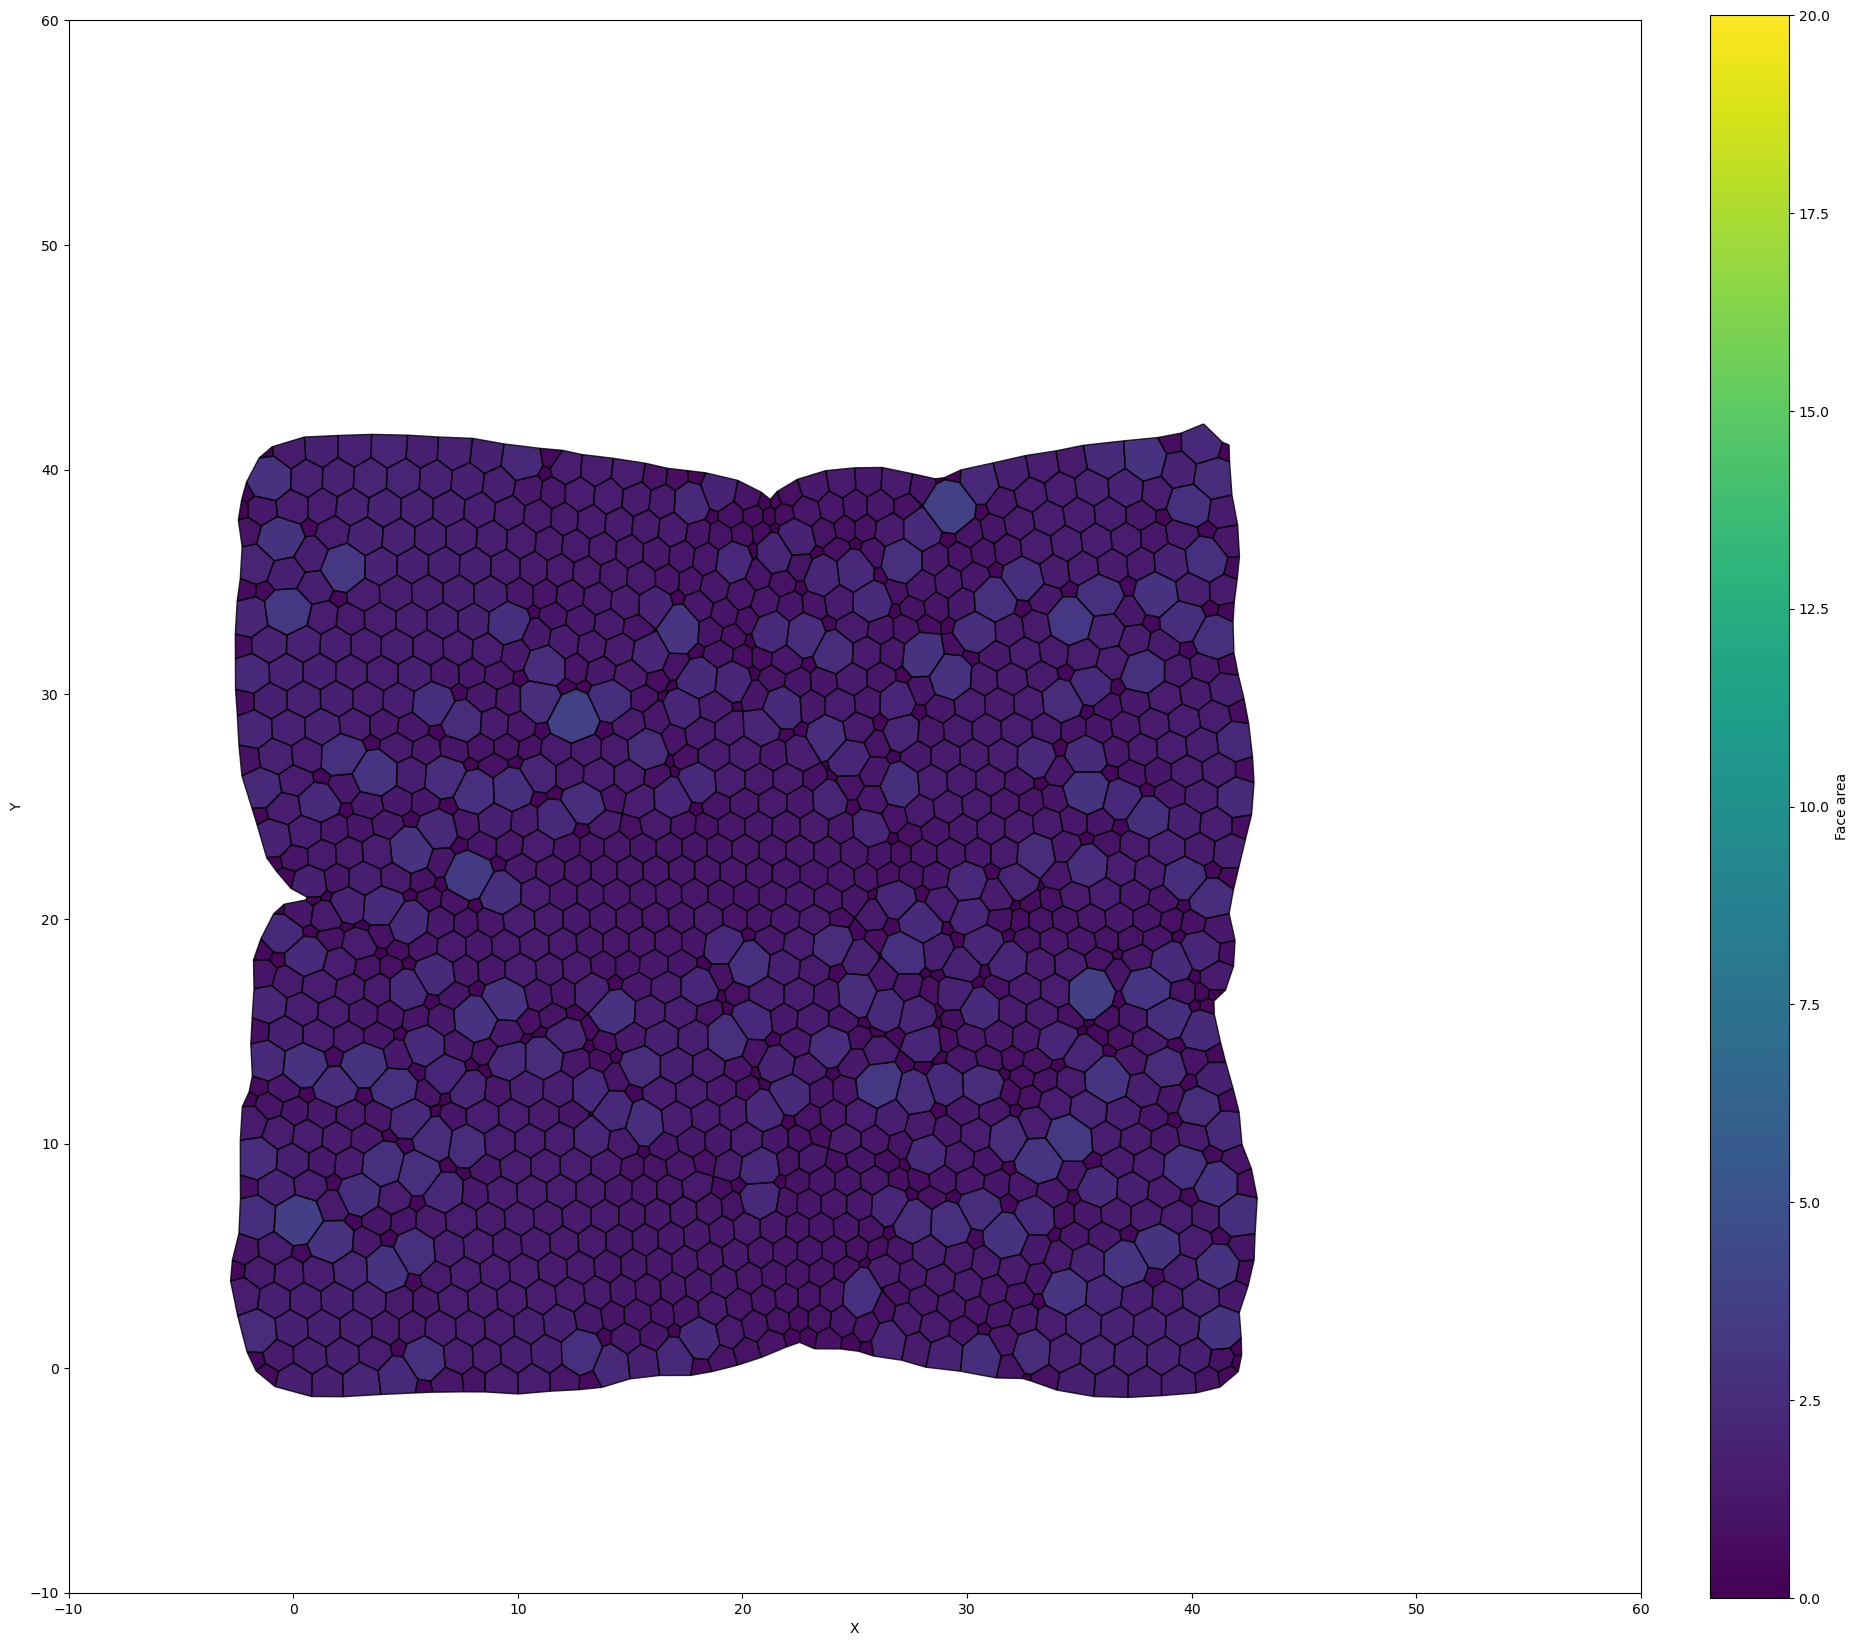

(<Figure size 2000x2000 with 2 Axes>, <Axes: xlabel='X', ylabel='Y'>)

In [127]:
heatmap_of_faces_area_fixed_norm(
    cellmap,
    0,
    20,
    cmap_name="viridis",
    show_colorbar=True,
    show_axes=True,
    xlim=(-10,60),
    ylim=(-10,60),
    axis_equal=True)

### change edge mechanics

In [128]:

#cellmap.edge_df['line_tension'] = 380*1.2

patches = make_patches(cellmap, n_patches=50, fraction=0.1, seed=1)
high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=10, tension_col="length_elasticity")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=0.001, tension_col="prefered_length")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=10, tension_col="line_tension")


cellmap.reset_topo()



In [ ]:


def colour_edges_binary(
    cellmap,
    geom,
    col="length_elasticity",
    low_colour="lightgrey",
    high_colour="red",
    threshold=None,
    width=3.0,
    show_axes=True,
    xlim=None,
    ylim=None,
    tick_spacing=None,
):

    geom.update_all(cellmap)

    values = cellmap.edge_df[col].to_numpy()

    # If threshold not given, split at midpoint
    if threshold is None:
        threshold = 0.5 * (values.min() + values.max())

    # 0 = low, 1 = high
    mask = (values > threshold).astype(float)

    cellmap.edge_df["edge_width"] = width
    cellmap.edge_df["binary_color"] = mask

    # Create 2-colour colormap
    cmap = ListedColormap([low_colour, high_colour])
    cmap_name = "binary_tmp"

    try:
        plt.colormaps.register(cmap, name=cmap_name, force=True)
    except:
        plt.register_cmap(name=cmap_name, cmap=cmap)

    specs = {
        "face": {"visible": False},
        "edge": {
            "visible": True,
            "color": cellmap.edge_df["binary_color"],
            "colormap": cmap_name,
            "width": cellmap.edge_df["edge_width"],
            "alpha": 1.0,
            "head_width": 0.0,
            "vmin": 0,
            "vmax": 1,
        },
        "vert": {"visible": False},
    }

    fig, ax = sheet_view(cellmap, mode="2D", **specs)
    fig.set_size_inches(15, 15)

    # ---------------------
    # Axis control
    # ---------------------
    ax.set_aspect("equal")

    if show_axes:
        ax.set_axis_on()
        ax.set_xlabel("X")
        ax.set_ylabel("Y")

        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)

        if tick_spacing is not None:
            ax.xaxis.set_major_locator(MultipleLocator(tick_spacing))
            ax.yaxis.set_major_locator(MultipleLocator(tick_spacing))
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    return fig, ax


/tmp/ipykernel_11035/1665435617.py:38: UserWarning: Overwriting the cmap 'binary_tmp' that was already in the registry.
  plt.colormaps.register(cmap, name=cmap_name, force=True)


(<Figure size 1500x1500 with 1 Axes>, <Axes: xlabel='X', ylabel='Y'>)

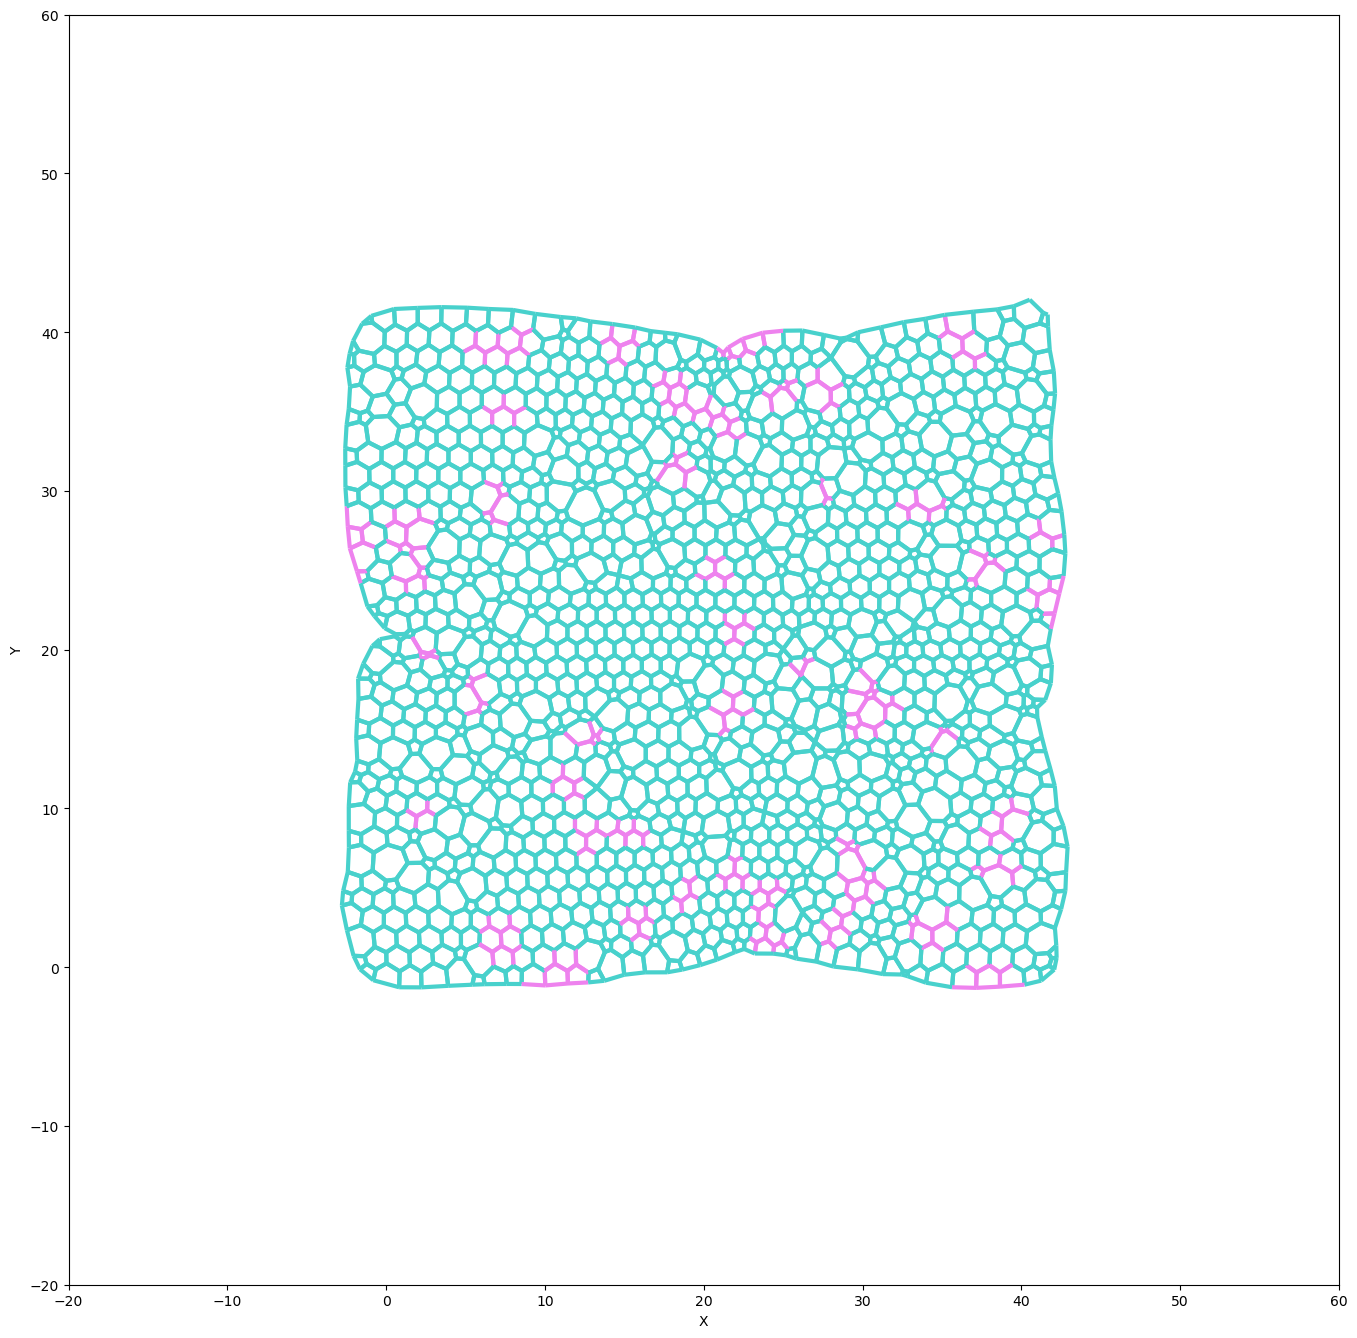

In [116]:
colour_edges_binary(
    cellmap,
    geom,
    col="line_tension",
    low_colour="mediumturquoise",
    high_colour="violet",
    threshold=None,
    width=3.0,
    show_axes=True,
    xlim=(-20,60),
    ylim=(-20,60),
    tick_spacing=None,
)

In [ ]:
def plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=None,
    col="length_elasticity",
    low_colour="mediumturquoise",
    high_colour="violet",
    threshold=None,
    width=3.0,
    show_axes=True,
    xlim=(-20, 60),
    ylim=(-20, 60),
    tick_spacing=None,
    new_vert_colour="red",
    new_vert_size=80,
    figsize=(10, 10),
    title=None,
    show_old_vertices=False,
):
    """
    Plot cellmap with edges coloured by a property (like length_elasticity)
    and highlight new vertices in red.
    
    Parameters:
    -----------
    cellmap : Tyssue cellmap
    geom : Geometry object
    new_vert_ids : list
        List of vertex indices to highlight in red (new division vertices)
    col : str
        Column name for edge colouring
    low_colour : str
        Colour for low values
    high_colour : str
        Colour for high values
    threshold : float or None
        If None, continuous colouring. If float, binary colouring.
    width : float
        Edge width
    show_axes : bool
        Show axes labels
    xlim, ylim : tuple
        Axis limits
    tick_spacing : float or None
        Spacing between ticks
    new_vert_colour : str
        Colour for new vertices
    new_vert_size : float
        Size of new vertices
    figsize : tuple
        Figure size
    title : str or None
        Plot title
    show_old_vertices : bool, default=False
        Whether to show non-divided vertices (if False, alpha=0)
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes
    """
   
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    coords = cellmap.coords[:2]
    edge_df = cellmap.edge_df
    vert_df = cellmap.vert_df
    
    # ============================================================
    # 1. Draw edges with colour_edges_binary style
    # ============================================================
    
    values = edge_df[col].values
    
    # Determine colours for each edge
    if threshold is None:
        # Continuous colouring
        vmin, vmax = values.min(), values.max()
        if vmax > vmin:
            norm = Normalize(vmin, vmax)
        else:
            norm = Normalize(0, 1)
        
        # Create custom colormap
        cmap = LinearSegmentedColormap.from_list('custom', [low_colour, high_colour])
        edge_colours = cmap(norm(values))
    else:
        # Binary colouring
        edge_colours = []
        for val in values:
            if val >= threshold:
                edge_colours.append(high_colour)
            else:
                edge_colours.append(low_colour)
    
    # Draw each edge with its colour
    for idx, row in edge_df.iterrows():
        srce = row['srce']
        trgt = row['trgt']
        
        x1 = vert_df.loc[srce, coords[0]]
        y1 = vert_df.loc[srce, coords[1]]
        x2 = vert_df.loc[trgt, coords[0]]
        y2 = vert_df.loc[trgt, coords[1]]
        
        colour = edge_colours[idx]
        
        ax.plot(
            [x1, x2], [y1, y2],
            color=colour,
            linewidth=width,
            solid_capstyle='round',
            zorder=1,
            alpha=0.9,
        )
    
    # ============================================================
    # 2. Draw ALL vertices (grey) - with alpha controlled
    # ============================================================
    
    x = vert_df[coords[0]].values
    y = vert_df[coords[1]].values
    
    # If show_old_vertices is False, alpha = 0 (invisible)
    vert_alpha = 0.7 if show_old_vertices else 0.0
    
    ax.scatter(
        x, y,
        color='lightgrey',
        s=30,
        alpha=vert_alpha,
        zorder=2,
        edgecolor='darkgrey',
        linewidth=0.5,
    )
    
    # ============================================================
    # 3. Draw NEW vertices (red) - if provided
    # ============================================================
    
    if new_vert_ids is not None and len(new_vert_ids) > 0:
        # Filter to only existing vertices
        existing_verts = set(vert_df.index)
        valid_new_verts = [v for v in new_vert_ids if v in existing_verts]
        
        if len(valid_new_verts) > 0:
            new_x = vert_df.loc[valid_new_verts, coords[0]].values
            new_y = vert_df.loc[valid_new_verts, coords[1]].values
            
            ax.scatter(
                new_x, new_y,
                color=new_vert_colour,
                s=new_vert_size,
                alpha=1.0,
                zorder=3,
                edgecolor='darkred',
                linewidth=1.5,
            )
            
            print(f"  ✓ Highlighted {len(valid_new_verts)} new vertices in {new_vert_colour}")
    
    # ============================================================
    # 4. Format plot
    # ============================================================
    
    ax.set_aspect('equal')
    
    if show_axes:
        ax.set_xlabel("X", fontsize=14)
        ax.set_ylabel("Y", fontsize=14)
        if tick_spacing is not None:
            ax.set_xticks(np.arange(xlim[0], xlim[1] + tick_spacing, tick_spacing))
            ax.set_yticks(np.arange(ylim[0], ylim[1] + tick_spacing, tick_spacing))
    else:
        ax.set_xticks([])
        ax.set_yticks([])
    
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    
    if title is not None:
        ax.set_title(title, fontsize=14)
    
    plt.tight_layout()
    
    return fig, ax

  ✓ Highlighted 1 new vertices in red


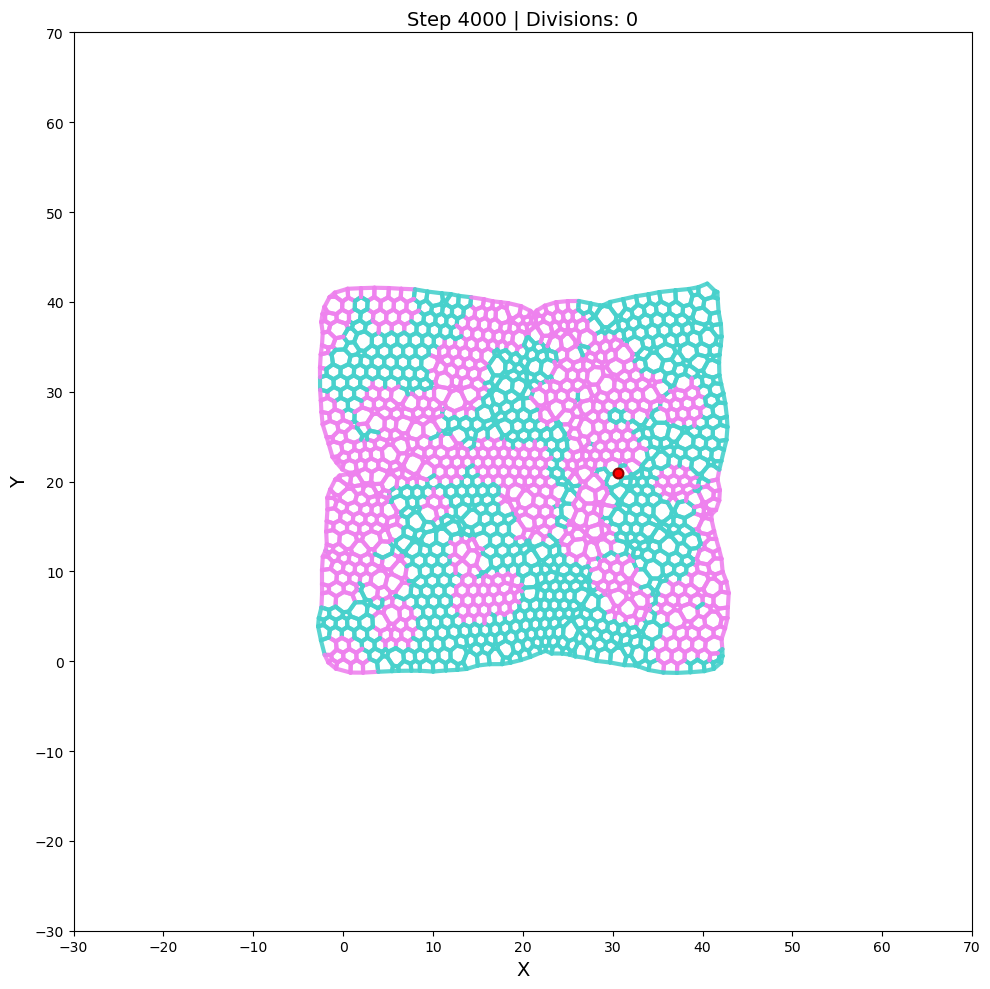

In [74]:
# In your main loop, after divisions and relaxation:

# Find vertices born at this step
new_vert_ids = cellmap.vert_df[cellmap.vert_df["birth_step"] == 3500].index.tolist()

# Create the plot (without saving)
fig, ax = plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=new_vert_ids,
    col="length_elasticity",
    low_colour="mediumturquoise",
    high_colour="violet",
    threshold=None,
    width=3.0,
    show_axes=True,
    xlim=(-30, 70),
    ylim=(-30, 70),
    tick_spacing=10,
    new_vert_colour="red",
    new_vert_size=50,
    figsize=(10, 10),
    title=f"Step {current_step} | Divisions: {current_divisions}",
    show_old_vertices=False,
)


### run more expansion 

In [23]:
def split_vertex(cellmap, chosen_vertex, geom, energyContributions_model, distance, retry_attempts=3):
    """
    Safely divide a vertex by creating a nearby new vertex and rewiring edges.
    On failure, rollback and retry up to `retry_attempts` times.

    Returns:
        (cellmap, chosen_vertex, new_vert_index, new_edge_index, opposite_edge_index)
        or (cellmap, chosen_vertex, None, None, None) if all attempts fail.
    """

    original_vert_df = cellmap.vert_df.copy()
    original_edge_df = cellmap.edge_df.copy()

    new_vert_index = None
    new_edge_index = None
    opposite_edge_index = None

    attempt = 0
    while attempt < retry_attempts:
        try:
            # --- Work on temporary copies ---
            temp_vert_df = cellmap.vert_df.copy()
            temp_edge_df = cellmap.edge_df.copy()

            # 1) Find connected edges
            connected_edges = temp_edge_df[
                (temp_edge_df['srce'] == chosen_vertex) |
                (temp_edge_df['trgt'] == chosen_vertex)
            ].copy()

            # 2) Create new vertex nearby
            new_vert_data = temp_vert_df.loc[chosen_vertex].copy()
            angle = np.random.uniform(0, 2*np.pi)
            dx = distance * np.cos(angle)
            dy = distance * np.sin(angle)
            new_vert_data[cellmap.coords] = temp_vert_df.loc[chosen_vertex, cellmap.coords] + [dx, dy]

            new_vert_index = int(temp_vert_df.index.max()) + 1
            temp_vert_df.loc[new_vert_index] = new_vert_data
    
        
            # 3) Create a pair of edges
            # Template: first connected edge (copies all mechanical properties)

            source_edge = connected_edges.iloc[0]

            template = source_edge.copy()

            new_edge_index = int(temp_edge_df.index.max()) + 1
            opposite_edge_index = new_edge_index + 1

            new_edge = template.copy()
            new_edge["srce"], new_edge["trgt"] = chosen_vertex, new_vert_index
            new_edge["face"] = np.nan

            opposite_edge = template.copy()
            opposite_edge["srce"], opposite_edge["trgt"] = new_vert_index, chosen_vertex
            opposite_edge["face"] = np.nan

            temp_edge_df.loc[new_edge_index] = new_edge
            temp_edge_df.loc[opposite_edge_index] = opposite_edge

            # 4) Reassign original edges to closer vertex
            chosen_xy = temp_vert_df.loc[chosen_vertex, cellmap.coords].values.astype(float)
            new_xy    = temp_vert_df.loc[new_vert_index, cellmap.coords].values.astype(float)

            reassigned_edges_to_new_vertex = []
            for e_idx, e in connected_edges.iterrows():
                if e_idx in (new_edge_index, opposite_edge_index):
                    continue
                other = e['trgt'] if e['srce'] == chosen_vertex else e['srce']
                other_xy = temp_vert_df.loc[other, cellmap.coords].values.astype(float)

                d_chosen = np.linalg.norm(other_xy - chosen_xy)
                d_new    = np.linalg.norm(other_xy - new_xy)

                if d_new < d_chosen:
                    reassigned_edges_to_new_vertex.append(e_idx)
                    if e['srce'] == chosen_vertex:
                        temp_edge_df.loc[e_idx, 'srce'] = new_vert_index
                    else:
                        temp_edge_df.loc[e_idx, 'trgt'] = new_vert_index

            # 5) Identify "open" faces (whose edge chains don't close)
            open_faces = []
            for face_id, group in temp_edge_df.groupby('face'):
                verts = list(group[['srce', 'trgt']].itertuples(index=False, name=None))
                if not verts:
                    continue

                # try to follow the loop
                chain = [verts[0][0], verts[0][1]]
                used = {0}
                while True:
                    extended = False
                    for i, (s, t) in enumerate(verts):
                        if i in used:
                            continue
                        if chain[-1] == s:
                            chain.append(t)
                            used.add(i)
                            extended = True
                            break
                        elif chain[-1] == t:
                            chain.append(s)
                            used.add(i)
                            extended = True
                            break
                    if not extended:
                        break

                # if loop doesn't close, this face is "open"
                if chain[0] != chain[-1]:
                    open_faces.append(face_id)

            # filter: only faces touching the new vertex
            open_faces_touching_new = []
            for f in open_faces:
                verts_f = temp_edge_df[temp_edge_df['face'] == f][['srce', 'trgt']].values.ravel()
                if new_vert_index in verts_f or chosen_vertex in verts_f:
                    open_faces_touching_new.append(f)

            print("Open faces touching new vertex:", open_faces_touching_new)

            if len(open_faces_touching_new) != 2:
                raise ValueError(
                    f"Expected 2 open faces, found {len(open_faces_touching_new)}: {open_faces_touching_new}"
                )

            # --- Find which new edge closes which open face ---
            for f in open_faces_touching_new:
                f_edges = temp_edge_df[temp_edge_df['face'] == f]

                # collect src/trgt vertices
                srces = list(f_edges['srce'].astype(int))
                trgts = list(f_edges['trgt'].astype(int))

                # imbalance: start and end
                start_candidates = [v for v in srces if v not in trgts]
                end_candidates   = [v for v in trgts if v not in srces]

                if len(start_candidates) == 1 and len(end_candidates) == 1:
                    start = start_candidates[0]
                    end   = end_candidates[0]
                    needed_edge = (end, start)  # must go end→start to close loop

                    new_pair      = (int(temp_edge_df.loc[new_edge_index, 'srce']),
                                     int(temp_edge_df.loc[new_edge_index, 'trgt']))
                    opposite_pair = (int(temp_edge_df.loc[opposite_edge_index, 'srce']),
                                     int(temp_edge_df.loc[opposite_edge_index, 'trgt']))

                    if new_pair == needed_edge:
                        temp_edge_df.loc[new_edge_index, 'face'] = f
                    elif opposite_pair == needed_edge:
                        temp_edge_df.loc[opposite_edge_index, 'face'] = f
                    else:
                        print(f"Face {f}: expected {needed_edge}, "
                              f"but new={new_pair}, opp={opposite_pair}")
                        
            # --- 6) Verify both assigned faces are closed directed cycles; if not, swap once and recheck

            def _face_closes(df, face_id):
                sub = df[df['face'] == face_id][['srce', 'trgt']]
                # in==out at every vertex
                outc = sub['srce'].value_counts()
                inc  = sub['trgt'].value_counts()
                verts = set(outc.index) | set(inc.index)
                for v in verts:
                    if outc.get(v, 0) != inc.get(v, 0):
                        return False
                # follow edges as a walk using srce->trgt
                start = int(sub.iloc[0]['srce'])
                cur = start
                used = set()
                for _ in range(len(sub)):
                    nxt = sub[~sub.index.isin(used) & (sub['srce'] == cur)]
                    if nxt.empty:
                        return False
                    eidx = nxt.index[0]
                    used.add(eidx)
                    cur = int(sub.loc[eidx, 'trgt'])
                return cur == start and len(used) == len(sub)

            face_new = int(temp_edge_df.loc[new_edge_index, 'face'])
            face_opp = int(temp_edge_df.loc[opposite_edge_index, 'face'])

            ok_new = _face_closes(temp_edge_df, face_new)
            ok_opp = _face_closes(temp_edge_df, face_opp)

            if not (ok_new and ok_opp):
                # try swapping faces between the two new edges once
                temp_edge_df.loc[new_edge_index, 'face'], temp_edge_df.loc[opposite_edge_index, 'face'] = face_opp, face_new
                face_new, face_opp = face_opp, face_new
                ok_new = _face_closes(temp_edge_df, face_new)
                ok_opp = _face_closes(temp_edge_df, face_opp)

            if not (ok_new and ok_opp):
                raise ValueError(
                    f"Face closure failed after assignment: "
                    f"new→face {face_new} ok={ok_new}, opp→face {face_opp} ok={ok_opp}"
            )

            # 7) Commit temp results ---
            cellmap.vert_df = temp_vert_df
            cellmap.edge_df = temp_edge_df

            # Update geometry
            geom.update_all(cellmap)
            cellmap.reset_topo()
            cellmap.reset_index()

            # --- ADD ENERGY RELAXATION HERE ---
            energyContributions_model.compute_energy(cellmap)
            [cellmap, geom, model_H, history_H, solver] = vertexModel2.solveEuler(
                cellmap, geom, energyContributions_model, endTime=40
            )

            print(f" Successfully divided vertex {chosen_vertex} → new vertex {new_vert_index}")
            return cellmap, chosen_vertex, new_vert_index, new_edge_index, opposite_edge_index

        except Exception as e:
            print(f" split_vertex attempt {attempt+1}/{retry_attempts} failed: {e}")
            # rollback original state
            cellmap.vert_df = original_vert_df.copy()
            cellmap.edge_df = original_edge_df.copy()
            geom.update_all(cellmap)
            cellmap.reset_topo()
            cellmap.reset_index()
            attempt += 1

    print("Failed to divide after multiple attempts.")
    return cellmap, chosen_vertex, None, None, None


All tracking columns exist ✓
Next vertex ID: 2777
Vertices with birth_step == 0: 2733
Vertices with birth_step == 3500: 1

Continuing expansion from step 3500
Total additional steps: 12000 (to step 15500)
Saving every 500 steps

Initial checkpoint saved at step 3500
  ✓ Highlighted 1 new vertices in red
Initial visualization saved at step 3500

Cycle 1: Step 4000
Found 0 vertices above threshold
Post-division checkpoint saved at step 4000
Relaxing for 500 steps...
Relaxation complete.
Checkpoint saved at step 4000
Visualization saved at step 4000

Cycle 2: Step 4500
Found 3 vertices above threshold
Open faces touching new vertex: [1303.0, 1340.0]
Topology changed!
 Successfully divided vertex 323.0 → new vertex 2749
Open faces touching new vertex: [1.0, 2.0]
Topology changed!
 Successfully divided vertex 1572.0 → new vertex 2750
Open faces touching new vertex: [3.0, 4.0]
Topology changed!
 Successfully divided vertex 2029.0 → new vertex 2751
Performed 3 divisions
Post-division checkpoi

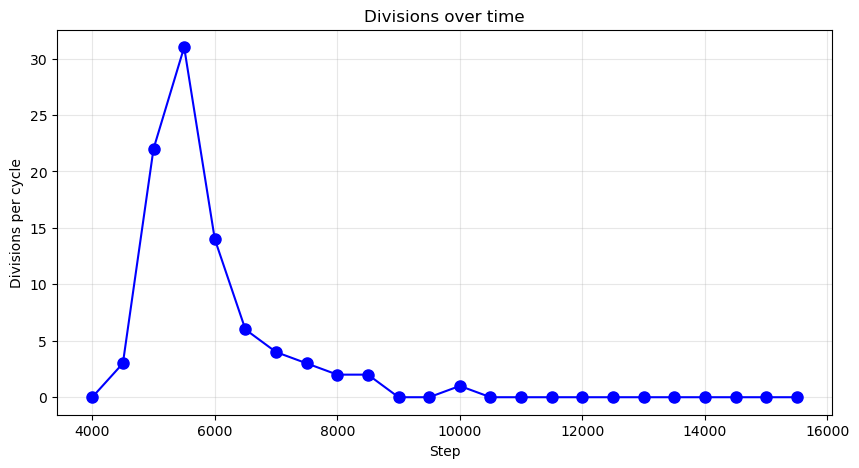

Visualization saved at step 15500
Final checkpoint saved to: Figure_6_reviewed/sim_1_10_per_edges_length_elasticity_10_times_higher_at_3500_time/checkpoint_final.pkl


In [129]:
# ============================================================
# 2. CHECK COLUMNS EXIST (don't create them)
# ============================================================

v = cellmap.vert_df

# Verify columns exist
required_cols = ["new_vert_id", "parent_vert_id", "birth_step", "divided_step"]
for col in required_cols:
    if col not in v.columns:
        raise ValueError(f"Column '{col}' missing from vert_df — this should NOT happen!")

print("All tracking columns exist ✓")

# Get next available ID for new vertices
next_new_vert_id = int(v["new_vert_id"].max()) + 1
print(f"Next vertex ID: {next_new_vert_id}")

# Check current birth_step distribution
print(f"Vertices with birth_step == 0: {len(v[v['birth_step'] == 0])}")
print(f"Vertices with birth_step == 3500: {len(v[v['birth_step'] == 3500])}")

# ============================================================
# 3. SETUP PARAMETERS
# ============================================================

# Simulation parameters — continue from 3500
TOTAL_STEPS = 12000           # Total additional steps (3500 → 18500)
STEPS_PER_CYCLE = 500         # Save every 500 steps
RELAX_STEPS = 500             # Steps to relax after divisions

# Division parameters
EDGE_SUM_THRESHOLD = 7
DIVISION_DISTANCE = 0.01

# Output directory
OUTPUT_DIR = "Figure_6_reviewed/sim_1_10_per_edges_length_elasticity_10_times_higher_at_3500_time"

# Starting step counter (continue from 3500)
STARTING_STEP = 3500

# ============================================================
# 4. DEFINE HELPER FUNCTIONS
# ============================================================

def relax(cellmap, nsteps: int):
    """Run mechanical relaxation without topological changes."""
    if nsteps <= 0:
        return cellmap
    energyContributions_model.compute_energy(cellmap)
    cellmap_out, _, _, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, int(nsteps)
    )
    return cellmap_out

def ensure_new_vert_ids(cellmap, next_id):
    """Assign unique IDs to any new vertices (from collapses etc)."""
    vdf = cellmap.vert_df
    if "new_vert_id" not in vdf.columns:
        vdf["new_vert_id"] = np.nan
    missing = vdf["new_vert_id"].isna()
    if missing.any():
        n = int(missing.sum())
        vdf.loc[missing, "new_vert_id"] = np.arange(next_id, next_id + n, dtype=int)
        next_id += n
    return next_id

def save_visualization_with_new_vertices(cellmap, geom, current_step, output_dir, divisions_count):
    """
    Create and save visualization with new vertices (birth_step == current_step) highlighted in red.
    """
    # Find vertices born at this step
    new_vert_ids = cellmap.vert_df[cellmap.vert_df["birth_step"] == current_step].index.tolist()
    
    fig, ax = plot_coloured_edges_with_new_vertices(
        cellmap,
        geom,
        new_vert_ids=new_vert_ids,
        col="length_elasticity",
        low_colour="mediumturquoise",
        high_colour="orchid",
        threshold=None,
        width=3.0,
        show_axes=True,
        xlim=(-30, 70),
        ylim=(-30, 70),
        tick_spacing=10,
        new_vert_colour="red",
        new_vert_size=100,
        figsize=(10, 10),
        title=f"Step {current_step} | Divisions: {divisions_count}",
        show_old_vertices=False,
    )
    
    plt.savefig(os.path.join(output_dir, f"progress_{current_step:06d}.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Visualization saved at step {current_step}")

# ============================================================
# 5. MAIN LOOP: EXPAND WITH DIVISIONS
# ============================================================

print(f"\n{'='*60}")
print(f"Continuing expansion from step {STARTING_STEP}")
print(f"Total additional steps: {TOTAL_STEPS} (to step {STARTING_STEP + TOTAL_STEPS})")
print(f"Saving every {STEPS_PER_CYCLE} steps")
print(f"{'='*60}\n")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Statistics
division_stats = []

# Save initial state at step 3500
initial_step = STARTING_STEP
with open(os.path.join(OUTPUT_DIR, f"checkpoint_{initial_step:06d}.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Initial checkpoint saved at step {initial_step}")

# Save initial visualization using the new style
# Find vertices born at step 3500 (should be from previous simulation)
new_vert_ids_initial = cellmap.vert_df[cellmap.vert_df["birth_step"] == initial_step].index.tolist()
fig, ax = plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=new_vert_ids_initial,
    col="length_elasticity",
    low_colour="mediumturquoise",
    high_colour="orchid",
    threshold=None,
    width=3.0,
    show_axes=True,
    xlim=(-30, 70),
    ylim=(-30, 70),
    tick_spacing=10,
    new_vert_colour="red",
    new_vert_size=100,
    figsize=(10, 10),
    title=f"Step {initial_step} | Starting point for expansion",
    show_old_vertices=False,
)
plt.savefig(os.path.join(OUTPUT_DIR, f"progress_{initial_step:06d}.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Initial visualization saved at step {initial_step}")

cellmap.face_df['prefered_area'] *= 1.2

# Main expansion loop
for cycle in range(1, int(TOTAL_STEPS / STEPS_PER_CYCLE) + 1):
    current_step = STARTING_STEP + cycle * STEPS_PER_CYCLE
    print(f"\n{'='*60}")
    print(f"Cycle {cycle}: Step {current_step}")
    print(f"{'='*60}")

    # --------------------------------------------------------
    # Step 1: Identify inside vertices
    # --------------------------------------------------------
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 2: Perform divisions
    # --------------------------------------------------------
    vertices_to_divide = []
    for v in inside_vertices:
        if v not in cellmap.vert_df.index:
            continue
        connected_edges = cellmap.edge_df[
            (cellmap.edge_df["srce"] == v) | (cellmap.edge_df["trgt"] == v)
        ]
        edge_sum = connected_edges["length"].sum()
        
        if edge_sum > EDGE_SUM_THRESHOLD:
            vertices_to_divide.append(v)
    
    print(f"Found {len(vertices_to_divide)} vertices above threshold")

    current_divisions = 0

    if len(vertices_to_divide) > 0:
        divided_count = 0
        
        for v in vertices_to_divide:  # NO CAP — try ALL vertices
            try:
                cellmap, parent_vert, new_vert, new_edge, opp_edge = split_vertex(
                    cellmap, v, geom, energyContributions_model, DIVISION_DISTANCE, retry_attempts=3
                )
                
                if new_vert is not None:
                    # Record lineage with existing columns
                    parent_id = int(cellmap.vert_df.loc[parent_vert, "new_vert_id"])
                    cellmap.vert_df.loc[parent_vert, "divided_step"] = current_step
                    cellmap.vert_df.loc[new_vert, "new_vert_id"] = next_new_vert_id
                    cellmap.vert_df.loc[new_vert, "parent_vert_id"] = parent_id
                    cellmap.vert_df.loc[new_vert, "birth_step"] = current_step
                    next_new_vert_id += 1
                    divided_count += 1
                    
            except Exception as e:
                print(f"  Warning: division failed for vertex {v}: {e}")
        
        current_divisions = divided_count
        print(f"Performed {current_divisions} divisions")

        cellmap.reset_index()
        cellmap.reset_topo()

    division_stats.append(current_divisions)

    # --------------------------------------------------------
    # Step 3: Save post-division checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}_postdiv.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"Post-division checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 4: Energy minimization / relaxation
    # --------------------------------------------------------
    print(f"Relaxing for {RELAX_STEPS} steps...")
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, RELAX_STEPS
    )
    print(f"Relaxation complete.")

    # --------------------------------------------------------
    # Step 5: Save checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"Checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 6: Save visualization using plot_coloured_edges_with_new_vertices
    # --------------------------------------------------------
    save_visualization_with_new_vertices(
        cellmap, 
        geom, 
        current_step, 
        OUTPUT_DIR, 
        current_divisions
    )

    # --------------------------------------------------------
    # Step 7: Update division stats
    # --------------------------------------------------------
    np.savetxt(os.path.join(OUTPUT_DIR, "division_stats.txt"), division_stats)

# ============================================================
# 6. FINAL SUMMARY
# ============================================================

print(f"\n{'='*60}")
print("EXPANSION COMPLETE!")
print(f"Total divisions: {sum(division_stats)}")
print(f"Final vertex count: {len(cellmap.vert_df)}")
print(f"Final edge count: {len(cellmap.edge_df)}")
print(f"Output saved to: {OUTPUT_DIR}")
print(f"{'='*60}")

# Plot division statistics
plt.figure(figsize=(10, 5))
steps = [STARTING_STEP + i * STEPS_PER_CYCLE for i in range(1, len(division_stats) + 1)]
plt.plot(steps, division_stats, 'bo-', markersize=8)
plt.xlabel('Step')
plt.ylabel('Divisions per cycle')
plt.title('Divisions over time')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, "division_stats_plot.png"), dpi=150)
plt.show()

# Save final visualization
save_visualization_with_new_vertices(
    cellmap, 
    geom, 
    STARTING_STEP + TOTAL_STEPS, 
    OUTPUT_DIR, 
    division_stats[-1] if division_stats else 0
)

# Save final cellmap
with open(os.path.join(OUTPUT_DIR, "checkpoint_final.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Final checkpoint saved to: {OUTPUT_DIR}/checkpoint_final.pkl")

In [ ]:
cellmap.vert_df

,y,is_active,x,viscosity,new_vert_id,parent_vert_id,birth_step,divided_step
vert,,,,,,,,
0,20.338783,1.0,16.628286,1334.0,0.0,NaN,0.0,NaN
1,21.320975,1.0,0.143236,10000.0,1.0,NaN,0.0,NaN
2,20.324823,1.0,15.609687,1334.0,2.0,NaN,0.0,NaN
3,20.822057,1.0,16.218581,1334.0,3.0,NaN,0.0,NaN
4,39.345545,1.0,19.470299,10000.0,4.0,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...
2744,9.812794,1.0,23.885382,1334.0,2772.0,NaN,NaN,NaN
2745,21.481792,1.0,26.094255,1334.0,2773.0,NaN,NaN,NaN
2746,20.878718,1.0,29.614169,1334.0,2774.0,NaN,NaN,3500.0


In [134]:
### new simulation

In [5]:
pwd

'/home/veronika/Documents/2D-lymph-node-vertex-model/notebooks/TDLNs'

In [43]:
with open(
    "notebooks/Simulations_with_remodelling_every_1000th_cycle/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_100_percent_div_3.5_1/checkpoint_003500.pkl",
    "rb"
) as f:
    cellmap = pickle.load(f)

In [44]:

#cellmap.edge_df['line_tension'] = 380*1.2

patches = make_patches(cellmap, n_patches=3, fraction=0.1, seed=5)
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=3, tension_col="length_elasticity")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=0.001, tension_col="prefered_length")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=1.5, tension_col="line_tension")


cellmap.reset_topo()



TypeError: object of type 'int' has no len()

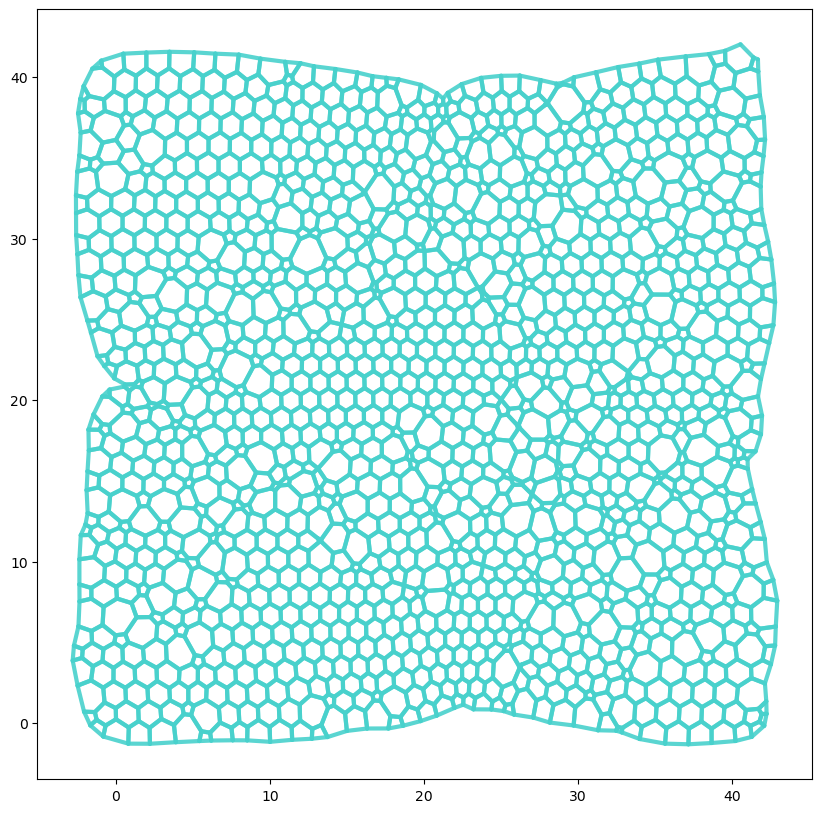

In [45]:
# Create the plot (without saving)
fig, ax = plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=1,
    col="length_elasticity",
    low_colour="mediumturquoise",
    high_colour="violet",
    threshold=155,
    width=3.0,
    show_axes=True,
    xlim=(-30, 70),
    ylim=(-30, 70),
    tick_spacing=10,
    new_vert_colour="red",
    new_vert_size=50,
    figsize=(10, 10),
    show_old_vertices=False,
)

In [46]:
# ============================================================
# 2. CHECK COLUMNS EXIST (don't create them)
# ============================================================

v = cellmap.vert_df

# Verify columns exist
required_cols = ["new_vert_id", "parent_vert_id", "birth_step", "divided_step"]
for col in required_cols:
    if col not in v.columns:
        raise ValueError(f"Column '{col}' missing from vert_df — this should NOT happen!")

print("All tracking columns exist ✓")

# Get next available ID for new vertices
next_new_vert_id = int(v["new_vert_id"].max()) + 1
print(f"Next vertex ID: {next_new_vert_id}")

# Check current birth_step distribution
print(f"Vertices with birth_step == 0: {len(v[v['birth_step'] == 0])}")
print(f"Vertices with birth_step == 3500: {len(v[v['birth_step'] == 3500])}")

# ============================================================
# 3. SETUP PARAMETERS
# ============================================================

# Simulation parameters — continue from 3500
TOTAL_STEPS = 12000           # Total additional steps (3500 → 18500)
STEPS_PER_CYCLE = 500         # Save every 500 steps
RELAX_STEPS = 500             # Steps to relax after divisions

# Division parameters
EDGE_SUM_THRESHOLD = 7
DIVISION_DISTANCE = 0.01

# Output directory
OUTPUT_DIR = "Figure_6_reviewed/no_changes_to_stroma_expansion"

# Starting step counter (continue from 3500)
STARTING_STEP = 3500

# ============================================================
# 4. DEFINE HELPER FUNCTIONS
# ============================================================

def relax(cellmap, nsteps: int):
    """Run mechanical relaxation without topological changes."""
    if nsteps <= 0:
        return cellmap
    energyContributions_model.compute_energy(cellmap)
    cellmap_out, _, _, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, int(nsteps)
    )
    return cellmap_out

def ensure_new_vert_ids(cellmap, next_id):
    """Assign unique IDs to any new vertices (from collapses etc)."""
    vdf = cellmap.vert_df
    if "new_vert_id" not in vdf.columns:
        vdf["new_vert_id"] = np.nan
    missing = vdf["new_vert_id"].isna()
    if missing.any():
        n = int(missing.sum())
        vdf.loc[missing, "new_vert_id"] = np.arange(next_id, next_id + n, dtype=int)
        next_id += n
    return next_id

def save_visualization_with_new_vertices(cellmap, geom, current_step, output_dir, divisions_count):
    """
    Create and save visualization with new vertices (birth_step == current_step) highlighted in red.
    """
    # Find vertices born at this step
    new_vert_ids = cellmap.vert_df[cellmap.vert_df["birth_step"] == current_step].index.tolist()
    
    fig, ax = plot_coloured_edges_with_new_vertices(
        cellmap,
        geom,
        new_vert_ids=new_vert_ids,
        col="length_elasticity",
        low_colour="mediumturquoise",
        high_colour="mediumturquoise",
        threshold=155,
        width=3.0,
        show_axes=True,
        xlim=(-40, 80),
        ylim=(-40, 80),
        tick_spacing=10,
        new_vert_colour="red",
        new_vert_size=100,
        figsize=(10, 10),
        title=f"Step {current_step} | Divisions: {divisions_count}",
        show_old_vertices=False,
    )
    
    plt.savefig(os.path.join(output_dir, f"progress_{current_step:06d}.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Visualization saved at step {current_step}")

# ============================================================
# 5. MAIN LOOP: EXPAND WITH DIVISIONS
# ============================================================

print(f"\n{'='*60}")
print(f"Continuing expansion from step {STARTING_STEP}")
print(f"Total additional steps: {TOTAL_STEPS} (to step {STARTING_STEP + TOTAL_STEPS})")
print(f"Saving every {STEPS_PER_CYCLE} steps")
print(f"{'='*60}\n")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Statistics
division_stats = []

# Save initial state at step 3500
initial_step = STARTING_STEP
with open(os.path.join(OUTPUT_DIR, f"checkpoint_{initial_step:06d}.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Initial checkpoint saved at step {initial_step}")

# Save initial visualization using the new style
# Find vertices born at step 3500 (should be from previous simulation)
new_vert_ids_initial = cellmap.vert_df[cellmap.vert_df["birth_step"] == initial_step].index.tolist()
fig, ax = plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=new_vert_ids_initial,
    col="length_elasticity",
    low_colour="mediumturquoise",
    high_colour="mediumturquoise",
    threshold=155,
    width=3.0,
    show_axes=True,
    xlim=(-40, 80),
    ylim=(-40, 80),
    tick_spacing=10,
    new_vert_colour="red",
    new_vert_size=100,
    figsize=(10, 10),
    title=f"Step {initial_step} | Starting point for expansion",
    show_old_vertices=False,
)
plt.savefig(os.path.join(OUTPUT_DIR, f"progress_{initial_step:06d}.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Initial visualization saved at step {initial_step}")

cellmap.face_df['prefered_area'] *= 1.2

# Main expansion loop
for cycle in range(1, int(TOTAL_STEPS / STEPS_PER_CYCLE) + 1):
    current_step = STARTING_STEP + cycle * STEPS_PER_CYCLE
    print(f"\n{'='*60}")
    print(f"Cycle {cycle}: Step {current_step}")
    print(f"{'='*60}")

    # --------------------------------------------------------
    # Step 1: Identify inside vertices
    # --------------------------------------------------------
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 2: Perform divisions
    # --------------------------------------------------------
    vertices_to_divide = []
    for v in inside_vertices:
        if v not in cellmap.vert_df.index:
            continue
        connected_edges = cellmap.edge_df[
            (cellmap.edge_df["srce"] == v) | (cellmap.edge_df["trgt"] == v)
        ]
        edge_sum = connected_edges["length"].sum()
        
        if edge_sum > EDGE_SUM_THRESHOLD:
            vertices_to_divide.append(v)
    
    print(f"Found {len(vertices_to_divide)} vertices above threshold")

    current_divisions = 0

    if len(vertices_to_divide) > 0:
        divided_count = 0
        
        for v in vertices_to_divide:  # NO CAP — try ALL vertices
            try:
                cellmap, parent_vert, new_vert, new_edge, opp_edge = split_vertex(
                    cellmap, v, geom, energyContributions_model, DIVISION_DISTANCE, retry_attempts=3
                )
                
                if new_vert is not None:
                    # Record lineage with existing columns
                    parent_id = int(cellmap.vert_df.loc[parent_vert, "new_vert_id"])
                    cellmap.vert_df.loc[parent_vert, "divided_step"] = current_step
                    cellmap.vert_df.loc[new_vert, "new_vert_id"] = next_new_vert_id
                    cellmap.vert_df.loc[new_vert, "parent_vert_id"] = parent_id
                    cellmap.vert_df.loc[new_vert, "birth_step"] = current_step
                    next_new_vert_id += 1
                    divided_count += 1
                    
            except Exception as e:
                print(f"  Warning: division failed for vertex {v}: {e}")
        
        current_divisions = divided_count
        print(f"Performed {current_divisions} divisions")

        cellmap.reset_index()
        cellmap.reset_topo()

    division_stats.append(current_divisions)

    # --------------------------------------------------------
    # Step 3: Save post-division checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}_postdiv.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"Post-division checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 4: Energy minimization / relaxation
    # --------------------------------------------------------
    print(f"Relaxing for {RELAX_STEPS} steps...")
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, RELAX_STEPS
    )
    print(f"Relaxation complete.")

    # --------------------------------------------------------
    # Step 5: Save checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"Checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 6: Save visualization using plot_coloured_edges_with_new_vertices
    # --------------------------------------------------------
    save_visualization_with_new_vertices(
        cellmap, 
        geom, 
        current_step, 
        OUTPUT_DIR, 
        current_divisions
    )

    # --------------------------------------------------------
    # Step 7: Update division stats
    # --------------------------------------------------------
    np.savetxt(os.path.join(OUTPUT_DIR, "division_stats.txt"), division_stats)

# ============================================================
# 6. FINAL SUMMARY
# ============================================================

print(f"\n{'='*60}")
print("EXPANSION COMPLETE!")
print(f"Total divisions: {sum(division_stats)}")
print(f"Final vertex count: {len(cellmap.vert_df)}")
print(f"Final edge count: {len(cellmap.edge_df)}")
print(f"Output saved to: {OUTPUT_DIR}")
print(f"{'='*60}")

# Plot division statistics
plt.figure(figsize=(10, 5))
steps = [STARTING_STEP + i * STEPS_PER_CYCLE for i in range(1, len(division_stats) + 1)]
plt.plot(steps, division_stats, 'bo-', markersize=8)
plt.xlabel('Step')
plt.ylabel('Divisions per cycle')
plt.title('Divisions over time')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, "division_stats_plot.png"), dpi=150)
plt.show()

# Save final visualization
save_visualization_with_new_vertices(
    cellmap, 
    geom, 
    STARTING_STEP + TOTAL_STEPS, 
    OUTPUT_DIR, 
    division_stats[-1] if division_stats else 0
)

# Save final cellmap
with open(os.path.join(OUTPUT_DIR, "checkpoint_final.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Final checkpoint saved to: {OUTPUT_DIR}/checkpoint_final.pkl")

All tracking columns exist ✓
Next vertex ID: 2777
Vertices with birth_step == 0: 2733
Vertices with birth_step == 3500: 1

Continuing expansion from step 3500
Total additional steps: 12000 (to step 15500)
Saving every 500 steps

Initial checkpoint saved at step 3500
  ✓ Highlighted 1 new vertices in red
Initial visualization saved at step 3500

Cycle 1: Step 4000
Found 0 vertices above threshold
Post-division checkpoint saved at step 4000
Relaxing for 500 steps...
Relaxation complete.
Checkpoint saved at step 4000
Visualization saved at step 4000

Cycle 2: Step 4500
Found 2 vertices above threshold
Performed 0 divisions
Post-division checkpoint saved at step 4500
Relaxing for 500 steps...
Topology changed!
Relaxation complete.
Checkpoint saved at step 4500
Visualization saved at step 4500

Cycle 3: Step 5000
Found 6 vertices above threshold
Performed 0 divisions
Post-division checkpoint saved at step 5000
Relaxing for 500 steps...
Topology changed!
Relaxation complete.
Checkpoint saved

KeyboardInterrupt: 

In [12]:
pwd

'/home/veronika/Documents/2D-lymph-node-vertex-model/notebooks/TDLNs'

### WITH APOPTOSIS

In [20]:
with open(
    "../Simulations_with_remodelling_every_1000th_cycle/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_100_percent_div_3.5_2/checkpoint_003500.pkl",
    "rb"
) as f:
    cellmap = pickle.load(f)

In [21]:

#cellmap.edge_df['line_tension'] = 380*1.2

patches = make_patches(cellmap, n_patches=1, fraction=0.3, seed=1)
high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=5, tension_col="length_elasticity")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=0.001, tension_col="prefered_length")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=1.2, tension_col="line_tension")


cellmap.reset_topo()



All tracking columns exist ✓
Next vertex ID: 2786
Vertices with birth_step == 0: 2728
Vertices with birth_step == 3500: 1

Continuing expansion from step 3500
Total additional steps: 12000 (to step 15500)
Saving every 500 steps

Initial checkpoint saved at step 3500
  ✓ Highlighted 1 new vertices in red
Initial visualization saved at step 3500

Cycle 1: Step 4000
Topology changed!
Topology changed!
Topology changed!
  Collapses: 3/3
Topology changed!
  Found 6 vertices above threshold
Open faces touching new vertex: [401.0, 476.0]
Topology changed!
 Successfully divided vertex 2715.0 → new vertex 2743
Open faces touching new vertex: [1128.0, 1166.0]
Topology changed!
 Successfully divided vertex 2724.0 → new vertex 2744
Open faces touching new vertex: [138.0, 175.0]
Topology changed!
 Successfully divided vertex 2730.0 → new vertex 2745
Open faces touching new vertex: [974.0, 1049.0]
Topology changed!
 Successfully divided vertex 2732.0 → new vertex 2746
Open faces touching new vertex:

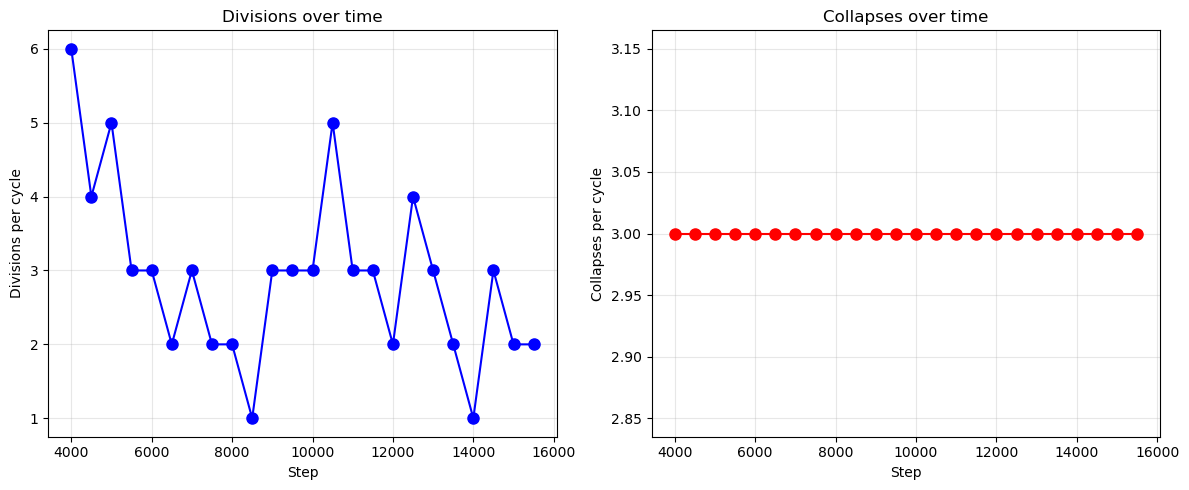

  ✓ Highlighted 2 new vertices in red
Visualization saved at step 15500
Final checkpoint saved to: ../../Figure_6_reviewed/with_apoptosis_0.0005/30_percent_length_elasticity_5_1_patches_seed_1_no_pressure_increase_3.5_div_sim_2/checkpoint_final.pkl


In [24]:
# ============================================================
# 2. CHECK COLUMNS EXIST (don't create them)
# ============================================================

v = cellmap.vert_df

# Verify columns exist
required_cols = ["new_vert_id", "parent_vert_id", "birth_step", "divided_step"]
for col in required_cols:
    if col not in v.columns:
        raise ValueError(f"Column '{col}' missing from vert_df — this should NOT happen!")

print("All tracking columns exist ✓")

# Get next available ID for new vertices
next_new_vert_id = int(v["new_vert_id"].max()) + 1
print(f"Next vertex ID: {next_new_vert_id}")

# Check current birth_step distribution
print(f"Vertices with birth_step == 0: {len(v[v['birth_step'] == 0])}")
print(f"Vertices with birth_step == 3500: {len(v[v['birth_step'] == 3500])}")

# ============================================================
# 3. SETUP PARAMETERS
# ============================================================

# Simulation parameters — continue from 3500
TOTAL_STEPS = 12000           # Total additional steps (3500 → 18500)
STEPS_PER_CYCLE = 500         # Save every 500 steps
RELAX_STEPS = 500             # Steps to relax after divisions

# Division parameters
EDGE_SUM_THRESHOLD = 3.5      # Changed back to original
DIVISION_DISTANCE = 0.01

# Collapse (apoptosis) parameters
COLLAPSE_FRACTION_PER_REMODEL = 0.0005  # 0.05% of inside edges per cycle
RELAX_AFTER_COLLAPSE = 10               # Relax steps after collapses

# Output directory
OUTPUT_DIR = "../../Figure_6_reviewed/with_apoptosis_0.0005/30_percent_length_elasticity_5_1_patches_seed_1_no_pressure_increase_3.5_div_sim_2"

# Starting step counter (continue from 3500)
STARTING_STEP = 3500

# ============================================================
# 4. DEFINE HELPER FUNCTIONS
# ============================================================

def relax(cellmap, nsteps: int):
    """Run mechanical relaxation without topological changes."""
    if nsteps <= 0:
        return cellmap
    energyContributions_model.compute_energy(cellmap)
    cellmap_out, _, _, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, int(nsteps)
    )
    return cellmap_out

def ensure_new_vert_ids(cellmap, next_id):
    """Assign unique IDs to any new vertices (from collapses etc)."""
    vdf = cellmap.vert_df
    if "new_vert_id" not in vdf.columns:
        vdf["new_vert_id"] = np.nan
    missing = vdf["new_vert_id"].isna()
    if missing.any():
        n = int(missing.sum())
        vdf.loc[missing, "new_vert_id"] = np.arange(next_id, next_id + n, dtype=int)
        next_id += n
    return next_id

def save_visualization_with_new_vertices(cellmap, geom, current_step, output_dir, divisions_count, collapses_count):
    """
    Create and save visualization with new vertices (birth_step == current_step) highlighted in red.
    """
    # Find vertices born at this step
    new_vert_ids = cellmap.vert_df[cellmap.vert_df["birth_step"] == current_step].index.tolist()
    
    fig, ax = plot_coloured_edges_with_new_vertices(
        cellmap,
        geom,
        new_vert_ids=new_vert_ids,
        col="length_elasticity",
        low_colour="mediumturquoise",
        high_colour="orchid",
        threshold=155,
        width=3.0,
        show_axes=True,
        xlim=(-30, 70),
        ylim=(-30, 70),
        tick_spacing=10,
        new_vert_colour="red",
        new_vert_size=100,
        figsize=(10, 10),
        title=f"Step {current_step} | Div: {divisions_count} | Col: {collapses_count}",
        show_old_vertices=False,
    )
    
    plt.savefig(os.path.join(output_dir, f"progress_{current_step:06d}.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Visualization saved at step {current_step}")

# ============================================================
# 5. MAIN LOOP: EXPAND WITH DIVISIONS & COLLAPSES
# ============================================================

print(f"\n{'='*60}")
print(f"Continuing expansion from step {STARTING_STEP}")
print(f"Total additional steps: {TOTAL_STEPS} (to step {STARTING_STEP + TOTAL_STEPS})")
print(f"Saving every {STEPS_PER_CYCLE} steps")
print(f"{'='*60}\n")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Statistics
division_stats = []
collapse_stats = []

# Save initial state at step 3500
initial_step = STARTING_STEP
with open(os.path.join(OUTPUT_DIR, f"checkpoint_{initial_step:06d}.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Initial checkpoint saved at step {initial_step}")

# Save initial visualization using the new style
new_vert_ids_initial = cellmap.vert_df[cellmap.vert_df["birth_step"] == initial_step].index.tolist()
fig, ax = plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=new_vert_ids_initial,
    col="length_elasticity",
    low_colour="mediumturquoise",
    high_colour="orchid",
    threshold=155,
    width=3.0,
    show_axes=True,
    xlim=(-30, 70),
    ylim=(-30, 70),
    tick_spacing=10,
    new_vert_colour="red",
    new_vert_size=100,
    figsize=(10, 10),
    title=f"Step {initial_step} | Starting point for expansion",
    show_old_vertices=False,
)
plt.savefig(os.path.join(OUTPUT_DIR, f"progress_{initial_step:06d}.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Initial visualization saved at step {initial_step}")

#cellmap.face_df['prefered_area'] *= 1.2

# Main expansion loop
for cycle in range(1, int(TOTAL_STEPS / STEPS_PER_CYCLE) + 1):
    current_step = STARTING_STEP + cycle * STEPS_PER_CYCLE
    print(f"\n{'='*60}")
    print(f"Cycle {cycle}: Step {current_step}")
    print(f"{'='*60}")

    # --------------------------------------------------------
    # Step 1: Identify inside vertices
    # --------------------------------------------------------
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 2: COLLAPSES (apoptosis)
    # --------------------------------------------------------
    current_collapses = 0
    
    # Identify inside edges
    valid_inside_edges = [e for e in inside_edges if e in cellmap.edge_df.index]
    n_inside = len(valid_inside_edges)
    target_collapse = int(np.floor(COLLAPSE_FRACTION_PER_REMODEL * n_inside))
    target_collapse = max(0, min(target_collapse, n_inside))
    
    if target_collapse > 0:
        edges_to_collapse = np.random.choice(valid_inside_edges, size=target_collapse, replace=False)
        for edge in edges_to_collapse:
            try:
                cellmap = collapse_single_edge(
                    cellmap, geom, energyContributions_model, edge
                )
                current_collapses += 1
            except Exception as e:
                print(f"  Warning: collapse failed for edge {edge}: {e}")
    
    print(f"  Collapses: {current_collapses}/{target_collapse}")
    
    # Reset indices after collapses
    cellmap.reset_index()
    cellmap.reset_topo()
    next_new_vert_id = ensure_new_vert_ids(cellmap, next_new_vert_id)
    
    # Relax after collapses
    if RELAX_AFTER_COLLAPSE > 0:
        cellmap = relax(cellmap, RELAX_AFTER_COLLAPSE)
        cellmap.reset_index()
        cellmap.reset_topo()
    
    # Re-identify boundaries after collapses
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 3: Perform divisions (using auxFunctionsExpansion.identify_vertices_to_divide)
    # --------------------------------------------------------
    vertices_to_divide = auxFunctionsExpansion.identify_vertices_to_divide(
        cellmap, inside_vertices, EDGE_SUM_THRESHOLD
    )
    
    print(f"  Found {len(vertices_to_divide)} vertices above threshold")

    current_divisions = 0

    if len(vertices_to_divide) > 0:
        divided_count = 0
        
        for v in vertices_to_divide:  # NO CAP — try ALL vertices
            try:
                cellmap, parent_vert, new_vert, new_edge, opp_edge = split_vertex(
                    cellmap, v, geom, energyContributions_model, DIVISION_DISTANCE, retry_attempts=3
                )
                
                if new_vert is not None:
                    # Record lineage with existing columns
                    parent_id = int(cellmap.vert_df.loc[parent_vert, "new_vert_id"])
                    cellmap.vert_df.loc[parent_vert, "divided_step"] = current_step
                    cellmap.vert_df.loc[new_vert, "new_vert_id"] = next_new_vert_id
                    cellmap.vert_df.loc[new_vert, "parent_vert_id"] = parent_id
                    cellmap.vert_df.loc[new_vert, "birth_step"] = current_step
                    next_new_vert_id += 1
                    divided_count += 1
                    
            except Exception as e:
                print(f"  Warning: division failed for vertex {v}: {e}")
        
        current_divisions = divided_count
        print(f"  Performed {current_divisions} divisions")

        cellmap.reset_index()
        cellmap.reset_topo()

    division_stats.append(current_divisions)
    collapse_stats.append(current_collapses)

    # --------------------------------------------------------
    # Step 4: Save post-division checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}_postdiv.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Post-division checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 5: Energy minimization / relaxation
    # --------------------------------------------------------
    print(f"  Relaxing for {RELAX_STEPS} steps...")
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, RELAX_STEPS
    )
    print(f"  Relaxation complete.")

    # --------------------------------------------------------
    # Step 6: Save checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 7: Save visualization
    # --------------------------------------------------------
    save_visualization_with_new_vertices(
        cellmap, 
        geom, 
        current_step, 
        OUTPUT_DIR, 
        current_divisions,
        current_collapses
    )

    # --------------------------------------------------------
    # Step 8: Update division stats
    # --------------------------------------------------------
    np.savetxt(os.path.join(OUTPUT_DIR, "division_stats.txt"), division_stats)
    np.savetxt(os.path.join(OUTPUT_DIR, "collapse_stats.txt"), collapse_stats)

# ============================================================
# 6. FINAL SUMMARY
# ============================================================

print(f"\n{'='*60}")
print("EXPANSION COMPLETE!")
print(f"Total divisions: {sum(division_stats)}")
print(f"Total collapses: {sum(collapse_stats)}")
print(f"Final vertex count: {len(cellmap.vert_df)}")
print(f"Final edge count: {len(cellmap.edge_df)}")
print(f"Output saved to: {OUTPUT_DIR}")
print(f"{'='*60}")
#
# Plot division and collapse statistics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

steps = [STARTING_STEP + i * STEPS_PER_CYCLE for i in range(1, len(division_stats) + 1)]

ax1.plot(steps, division_stats, 'bo-', markersize=8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Divisions per cycle')
ax1.set_title('Divisions over time')
ax1.grid(True, alpha=0.3)

ax2.plot(steps, collapse_stats, 'ro-', markersize=8)
ax2.set_xlabel('Step')
ax2.set_ylabel('Collapses per cycle')
ax2.set_title('Collapses over time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "division_collapse_stats.png"), dpi=150)
plt.show()

# Save final visualization
save_visualization_with_new_vertices(
    cellmap, 
    geom, 
    STARTING_STEP + TOTAL_STEPS, 
    OUTPUT_DIR, 
    division_stats[-1] if division_stats else 0,
    collapse_stats[-1] if collapse_stats else 0
)

# Save final cellmap
with open(os.path.join(OUTPUT_DIR, "checkpoint_final.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Final checkpoint saved to: {OUTPUT_DIR}/checkpoint_final.pkl")

In [343]:
with open(
    "../Simulations_with_remodelling_every_1000th_cycle/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_100_percent_div_3.5_3/checkpoint_003500.pkl",
    "rb"
) as f:
    cellmap = pickle.load(f)

In [344]:

#cellmap.edge_df['line_tension'] = 380*1.2

patches = make_patches(cellmap, n_patches=10, fraction=0.5, seed=1)
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=5, tension_col="length_elasticity")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=0.001, tension_col="prefered_length")
high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=1.2, tension_col="line_tension")


cellmap.reset_topo()



All tracking columns exist ✓
Next vertex ID: 2784
Vertices with birth_step == 0: 2742
Vertices with birth_step == 3500: 0

Continuing expansion from step 3500
Total additional steps: 12000 (to step 15500)
Saving every 500 steps

Initial checkpoint saved at step 3500
Initial visualization saved at step 3500

Cycle 1: Step 4000
Topology changed!
Topology changed!
Topology changed!
  Collapses: 3/3
Topology changed!
  Found 1 vertices above threshold
Open faces touching new vertex: [898.0, 934.0]
Topology changed!
 Successfully divided vertex 264.0 → new vertex 2753
  Performed 1 divisions
  Post-division checkpoint saved at step 4000
  Relaxing for 500 steps...
Topology changed!
  Relaxation complete.
  Checkpoint saved at step 4000
  ✓ Highlighted 1 new vertices in red
Visualization saved at step 4000

Cycle 2: Step 4500
Topology changed!
Topology changed!
Topology changed!
  Collapses: 3/3
Topology changed!
  Found 1 vertices above threshold
Open faces touching new vertex: [1155.0, 119

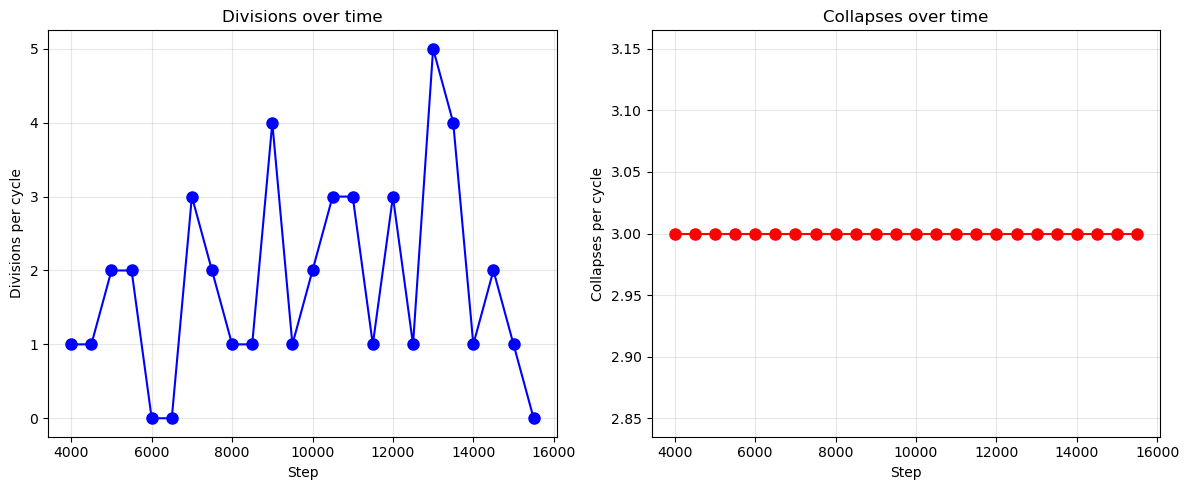

Visualization saved at step 15500
Final checkpoint saved to: ../../Figure_6_reviewed/with_apoptosis_0.0005/50_percent_line_tension_1.2_10_patches_seed_1_no_pressure_increase_3.5_div_sim_3/checkpoint_final.pkl


In [345]:
# ============================================================
# 2. CHECK COLUMNS EXIST (don't create them)
# ============================================================

v = cellmap.vert_df

# Verify columns exist
required_cols = ["new_vert_id", "parent_vert_id", "birth_step", "divided_step"]
for col in required_cols:
    if col not in v.columns:
        raise ValueError(f"Column '{col}' missing from vert_df — this should NOT happen!")

print("All tracking columns exist ✓")

# Get next available ID for new vertices
next_new_vert_id = int(v["new_vert_id"].max()) + 1
print(f"Next vertex ID: {next_new_vert_id}")

# Check current birth_step distribution
print(f"Vertices with birth_step == 0: {len(v[v['birth_step'] == 0])}")
print(f"Vertices with birth_step == 3500: {len(v[v['birth_step'] == 3500])}")

# ============================================================
# 3. SETUP PARAMETERS
# ============================================================

# Simulation parameters — continue from 3500
TOTAL_STEPS = 12000           # Total additional steps (3500 → 18500)
STEPS_PER_CYCLE = 500         # Save every 500 steps
RELAX_STEPS = 500             # Steps to relax after divisions

# Division parameters
EDGE_SUM_THRESHOLD = 3.5      # Changed back to original
DIVISION_DISTANCE = 0.01

# Collapse (apoptosis) parameters
COLLAPSE_FRACTION_PER_REMODEL = 0.0005  # 0.05% of inside edges per cycle
RELAX_AFTER_COLLAPSE = 10               # Relax steps after collapses

# Output directory
OUTPUT_DIR = "../../Figure_6_reviewed/with_apoptosis_0.0005/50_percent_line_tension_1.2_10_patches_seed_1_no_pressure_increase_3.5_div_sim_3"

# Starting step counter (continue from 3500)
STARTING_STEP = 3500

# ============================================================
# 4. DEFINE HELPER FUNCTIONS
# ============================================================

def relax(cellmap, nsteps: int):
    """Run mechanical relaxation without topological changes."""
    if nsteps <= 0:
        return cellmap
    energyContributions_model.compute_energy(cellmap)
    cellmap_out, _, _, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, int(nsteps)
    )
    return cellmap_out

def ensure_new_vert_ids(cellmap, next_id):
    """Assign unique IDs to any new vertices (from collapses etc)."""
    vdf = cellmap.vert_df
    if "new_vert_id" not in vdf.columns:
        vdf["new_vert_id"] = np.nan
    missing = vdf["new_vert_id"].isna()
    if missing.any():
        n = int(missing.sum())
        vdf.loc[missing, "new_vert_id"] = np.arange(next_id, next_id + n, dtype=int)
        next_id += n
    return next_id

def save_visualization_with_new_vertices(cellmap, geom, current_step, output_dir, divisions_count, collapses_count):
    """
    Create and save visualization with new vertices (birth_step == current_step) highlighted in red.
    """
    # Find vertices born at this step
    new_vert_ids = cellmap.vert_df[cellmap.vert_df["birth_step"] == current_step].index.tolist()
    
    fig, ax = plot_coloured_edges_with_new_vertices(
        cellmap,
        geom,
        new_vert_ids=new_vert_ids,
        col="line_tension",
        low_colour="mediumturquoise",
        high_colour="orange",
        threshold=155,
        width=3.0,
        show_axes=True,
        xlim=(-30, 70),
        ylim=(-30, 70),
        tick_spacing=10,
        new_vert_colour="red",
        new_vert_size=100,
        figsize=(10, 10),
        title=f"Step {current_step} | Div: {divisions_count} | Col: {collapses_count}",
        show_old_vertices=False,
    )
    
    plt.savefig(os.path.join(output_dir, f"progress_{current_step:06d}.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Visualization saved at step {current_step}")

# ============================================================
# 5. MAIN LOOP: EXPAND WITH DIVISIONS & COLLAPSES
# ============================================================

print(f"\n{'='*60}")
print(f"Continuing expansion from step {STARTING_STEP}")
print(f"Total additional steps: {TOTAL_STEPS} (to step {STARTING_STEP + TOTAL_STEPS})")
print(f"Saving every {STEPS_PER_CYCLE} steps")
print(f"{'='*60}\n")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Statistics
division_stats = []
collapse_stats = []

# Save initial state at step 3500
initial_step = STARTING_STEP
with open(os.path.join(OUTPUT_DIR, f"checkpoint_{initial_step:06d}.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Initial checkpoint saved at step {initial_step}")

# Save initial visualization using the new style
new_vert_ids_initial = cellmap.vert_df[cellmap.vert_df["birth_step"] == initial_step].index.tolist()
fig, ax = plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=new_vert_ids_initial,
    col="line_tension",
    low_colour="mediumturquoise",
    high_colour="orange",
    threshold=155,
    width=3.0,
    show_axes=True,
    xlim=(-30, 70),
    ylim=(-30, 70),
    tick_spacing=10,
    new_vert_colour="red",
    new_vert_size=100,
    figsize=(10, 10),
    title=f"Step {initial_step} | Starting point for expansion",
    show_old_vertices=False,
)
plt.savefig(os.path.join(OUTPUT_DIR, f"progress_{initial_step:06d}.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Initial visualization saved at step {initial_step}")

#cellmap.face_df['prefered_area'] *= 1.2

# Main expansion loop
for cycle in range(1, int(TOTAL_STEPS / STEPS_PER_CYCLE) + 1):
    current_step = STARTING_STEP + cycle * STEPS_PER_CYCLE
    print(f"\n{'='*60}")
    print(f"Cycle {cycle}: Step {current_step}")
    print(f"{'='*60}")

    # --------------------------------------------------------
    # Step 1: Identify inside vertices
    # --------------------------------------------------------
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 2: COLLAPSES (apoptosis)
    # --------------------------------------------------------
    current_collapses = 0
    
    # Identify inside edges
    valid_inside_edges = [e for e in inside_edges if e in cellmap.edge_df.index]
    n_inside = len(valid_inside_edges)
    target_collapse = int(np.floor(COLLAPSE_FRACTION_PER_REMODEL * n_inside))
    target_collapse = max(0, min(target_collapse, n_inside))
    
    if target_collapse > 0:
        edges_to_collapse = np.random.choice(valid_inside_edges, size=target_collapse, replace=False)
        for edge in edges_to_collapse:
            try:
                cellmap = collapse_single_edge(
                    cellmap, geom, energyContributions_model, edge
                )
                current_collapses += 1
            except Exception as e:
                print(f"  Warning: collapse failed for edge {edge}: {e}")
    
    print(f"  Collapses: {current_collapses}/{target_collapse}")
    
    # Reset indices after collapses
    cellmap.reset_index()
    cellmap.reset_topo()
    next_new_vert_id = ensure_new_vert_ids(cellmap, next_new_vert_id)
    
    # Relax after collapses
    if RELAX_AFTER_COLLAPSE > 0:
        cellmap = relax(cellmap, RELAX_AFTER_COLLAPSE)
        cellmap.reset_index()
        cellmap.reset_topo()
    
    # Re-identify boundaries after collapses
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 3: Perform divisions (using auxFunctionsExpansion.identify_vertices_to_divide)
    # --------------------------------------------------------
    vertices_to_divide = auxFunctionsExpansion.identify_vertices_to_divide(
        cellmap, inside_vertices, EDGE_SUM_THRESHOLD
    )
    
    print(f"  Found {len(vertices_to_divide)} vertices above threshold")

    current_divisions = 0

    if len(vertices_to_divide) > 0:
        divided_count = 0
        
        for v in vertices_to_divide:  # NO CAP — try ALL vertices
            try:
                cellmap, parent_vert, new_vert, new_edge, opp_edge = split_vertex(
                    cellmap, v, geom, energyContributions_model, DIVISION_DISTANCE, retry_attempts=3
                )
                
                if new_vert is not None:
                    # Record lineage with existing columns
                    parent_id = int(cellmap.vert_df.loc[parent_vert, "new_vert_id"])
                    cellmap.vert_df.loc[parent_vert, "divided_step"] = current_step
                    cellmap.vert_df.loc[new_vert, "new_vert_id"] = next_new_vert_id
                    cellmap.vert_df.loc[new_vert, "parent_vert_id"] = parent_id
                    cellmap.vert_df.loc[new_vert, "birth_step"] = current_step
                    next_new_vert_id += 1
                    divided_count += 1
                    
            except Exception as e:
                print(f"  Warning: division failed for vertex {v}: {e}")
        
        current_divisions = divided_count
        print(f"  Performed {current_divisions} divisions")

        cellmap.reset_index()
        cellmap.reset_topo()

    division_stats.append(current_divisions)
    collapse_stats.append(current_collapses)

    # --------------------------------------------------------
    # Step 4: Save post-division checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}_postdiv.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Post-division checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 5: Energy minimization / relaxation
    # --------------------------------------------------------
    print(f"  Relaxing for {RELAX_STEPS} steps...")
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, RELAX_STEPS
    )
    print(f"  Relaxation complete.")

    # --------------------------------------------------------
    # Step 6: Save checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 7: Save visualization
    # --------------------------------------------------------
    save_visualization_with_new_vertices(
        cellmap, 
        geom, 
        current_step, 
        OUTPUT_DIR, 
        current_divisions,
        current_collapses
    )

    # --------------------------------------------------------
    # Step 8: Update division stats
    # --------------------------------------------------------
    np.savetxt(os.path.join(OUTPUT_DIR, "division_stats.txt"), division_stats)
    np.savetxt(os.path.join(OUTPUT_DIR, "collapse_stats.txt"), collapse_stats)

# ============================================================
# 6. FINAL SUMMARY
# ============================================================

print(f"\n{'='*60}")
print("EXPANSION COMPLETE!")
print(f"Total divisions: {sum(division_stats)}")
print(f"Total collapses: {sum(collapse_stats)}")
print(f"Final vertex count: {len(cellmap.vert_df)}")
print(f"Final edge count: {len(cellmap.edge_df)}")
print(f"Output saved to: {OUTPUT_DIR}")
print(f"{'='*60}")
#
# Plot division and collapse statistics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

steps = [STARTING_STEP + i * STEPS_PER_CYCLE for i in range(1, len(division_stats) + 1)]

ax1.plot(steps, division_stats, 'bo-', markersize=8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Divisions per cycle')
ax1.set_title('Divisions over time')
ax1.grid(True, alpha=0.3)

ax2.plot(steps, collapse_stats, 'ro-', markersize=8)
ax2.set_xlabel('Step')
ax2.set_ylabel('Collapses per cycle')
ax2.set_title('Collapses over time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "division_collapse_stats.png"), dpi=150)
plt.show()

# Save final visualization
save_visualization_with_new_vertices(
    cellmap, 
    geom, 
    STARTING_STEP + TOTAL_STEPS, 
    OUTPUT_DIR, 
    division_stats[-1] if division_stats else 0,
    collapse_stats[-1] if collapse_stats else 0
)

# Save final cellmap
with open(os.path.join(OUTPUT_DIR, "checkpoint_final.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Final checkpoint saved to: {OUTPUT_DIR}/checkpoint_final.pkl")

### next simulation

In [119]:
cellmap.edge_df['line_tension'].unique()

array([ 60.,  76., 120., 152.])

In [1]:
with open(
    "../Simulations_with_remodelling_every_1000th_cycle/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_100_percent_div_3.5_2/checkpoint_003500.pkl",
    "rb"
) as f:
    cellmap = pickle.load(f)

NameError: name 'pickle' is not defined

In [347]:

#cellmap.edge_df['line_tension'] = 380*1.2

patches = make_patches(cellmap, n_patches=50, fraction=0.5, seed=1)
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=5, tension_col="length_elasticity")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=0.001, tension_col="prefered_length")
high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=1.2, tension_col="line_tension")


cellmap.reset_topo()



All tracking columns exist ✓
Next vertex ID: 2784
Vertices with birth_step == 0: 2742
Vertices with birth_step == 3500: 0

Continuing expansion from step 3500
Total additional steps: 12000 (to step 15500)
Saving every 500 steps

Initial checkpoint saved at step 3500
Initial visualization saved at step 3500

Cycle 1: Step 4000
Topology changed!
Topology changed!
Topology changed!
  Collapses: 3/3
Topology changed!
  Found 6 vertices above threshold
Open faces touching new vertex: [898.0, 935.0]
Topology changed!
 Successfully divided vertex 264.0 → new vertex 2753
Open faces touching new vertex: [148.0, 185.0]
Topology changed!
 Successfully divided vertex 605.0 → new vertex 2754
Open faces touching new vertex: [587.0, 662.0]
Topology changed!
 Successfully divided vertex 2737.0 → new vertex 2755
Open faces touching new vertex: [868.0, 943.0]
Topology changed!
 Successfully divided vertex 2741.0 → new vertex 2756
Open faces touching new vertex: [1200.0, 1274.0]
Topology changed!
 Succes

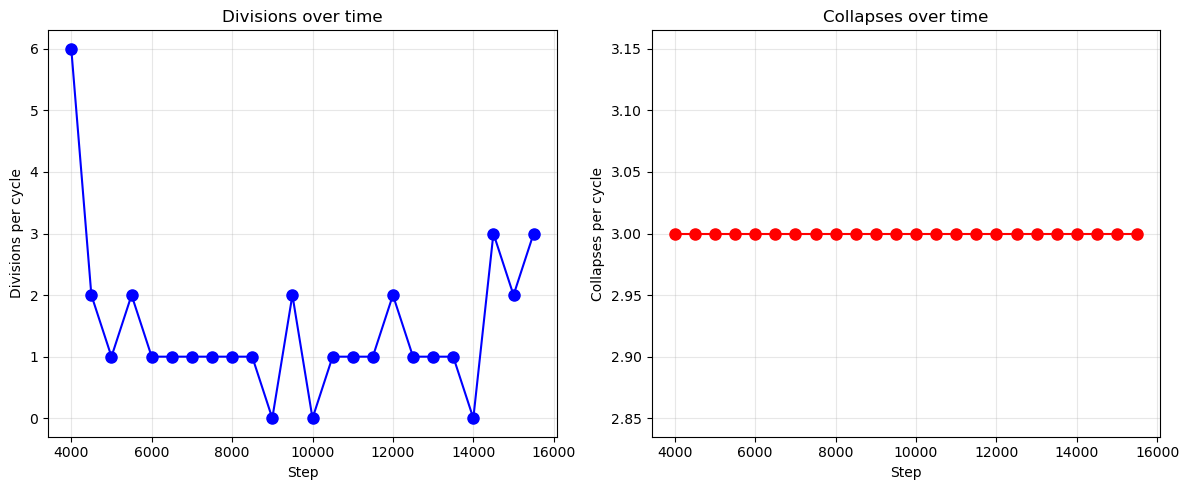

  ✓ Highlighted 3 new vertices in red
Visualization saved at step 15500
Final checkpoint saved to: ../../Figure_6_reviewed/with_apoptosis_0.0005/50_percent_line_tension_1.2_50_patches_seed_1_no_pressure_increase_3.5_div_sim_3/checkpoint_final.pkl


In [348]:
# ============================================================
# 2. CHECK COLUMNS EXIST (don't create them)
# ============================================================

v = cellmap.vert_df

# Verify columns exist
required_cols = ["new_vert_id", "parent_vert_id", "birth_step", "divided_step"]
for col in required_cols:
    if col not in v.columns:
        raise ValueError(f"Column '{col}' missing from vert_df — this should NOT happen!")

print("All tracking columns exist ✓")

# Get next available ID for new vertices
next_new_vert_id = int(v["new_vert_id"].max()) + 1
print(f"Next vertex ID: {next_new_vert_id}")

# Check current birth_step distribution
print(f"Vertices with birth_step == 0: {len(v[v['birth_step'] == 0])}")
print(f"Vertices with birth_step == 3500: {len(v[v['birth_step'] == 3500])}")

# ============================================================
# 3. SETUP PARAMETERS
# ============================================================

# Simulation parameters — continue from 3500
TOTAL_STEPS = 12000           # Total additional steps (3500 → 18500)
STEPS_PER_CYCLE = 500         # Save every 500 steps
RELAX_STEPS = 500             # Steps to relax after divisions

# Division parameters
EDGE_SUM_THRESHOLD = 3.5      # Changed back to original
DIVISION_DISTANCE = 0.01

# Collapse (apoptosis) parameters
COLLAPSE_FRACTION_PER_REMODEL = 0.0005  # 0.05% of inside edges per cycle
RELAX_AFTER_COLLAPSE = 10               # Relax steps after collapses

# Output directory
OUTPUT_DIR = "../../Figure_6_reviewed/with_apoptosis_0.0005/50_percent_line_tension_1.2_50_patches_seed_1_no_pressure_increase_3.5_div_sim_3"

# Starting step counter (continue from 3500)
STARTING_STEP = 3500

# ============================================================
# 4. DEFINE HELPER FUNCTIONS
# ============================================================

def relax(cellmap, nsteps: int):
    """Run mechanical relaxation without topological changes."""
    if nsteps <= 0:
        return cellmap
    energyContributions_model.compute_energy(cellmap)
    cellmap_out, _, _, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, int(nsteps)
    )
    return cellmap_out

def ensure_new_vert_ids(cellmap, next_id):
    """Assign unique IDs to any new vertices (from collapses etc)."""
    vdf = cellmap.vert_df
    if "new_vert_id" not in vdf.columns:
        vdf["new_vert_id"] = np.nan
    missing = vdf["new_vert_id"].isna()
    if missing.any():
        n = int(missing.sum())
        vdf.loc[missing, "new_vert_id"] = np.arange(next_id, next_id + n, dtype=int)
        next_id += n
    return next_id

def save_visualization_with_new_vertices(cellmap, geom, current_step, output_dir, divisions_count, collapses_count):
    """
    Create and save visualization with new vertices (birth_step == current_step) highlighted in red.
    """
    # Find vertices born at this step
    new_vert_ids = cellmap.vert_df[cellmap.vert_df["birth_step"] == current_step].index.tolist()
    
    fig, ax = plot_coloured_edges_with_new_vertices(
        cellmap,
        geom,
        new_vert_ids=new_vert_ids,
        col="line_tension",
        low_colour="mediumturquoise",
        high_colour="orange",
        threshold=155,
        width=3.0,
        show_axes=True,
        xlim=(-30, 70),
        ylim=(-30, 70),
        tick_spacing=10,
        new_vert_colour="red",
        new_vert_size=100,
        figsize=(10, 10),
        title=f"Step {current_step} | Div: {divisions_count} | Col: {collapses_count}",
        show_old_vertices=False,
    )
    
    plt.savefig(os.path.join(output_dir, f"progress_{current_step:06d}.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Visualization saved at step {current_step}")

# ============================================================
# 5. MAIN LOOP: EXPAND WITH DIVISIONS & COLLAPSES
# ============================================================

print(f"\n{'='*60}")
print(f"Continuing expansion from step {STARTING_STEP}")
print(f"Total additional steps: {TOTAL_STEPS} (to step {STARTING_STEP + TOTAL_STEPS})")
print(f"Saving every {STEPS_PER_CYCLE} steps")
print(f"{'='*60}\n")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Statistics
division_stats = []
collapse_stats = []

# Save initial state at step 3500
initial_step = STARTING_STEP
with open(os.path.join(OUTPUT_DIR, f"checkpoint_{initial_step:06d}.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Initial checkpoint saved at step {initial_step}")

# Save initial visualization using the new style
new_vert_ids_initial = cellmap.vert_df[cellmap.vert_df["birth_step"] == initial_step].index.tolist()
fig, ax = plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=new_vert_ids_initial,
    col="line_tension",
    low_colour="mediumturquoise",
    high_colour="orange",
    threshold=155,
    width=3.0,
    show_axes=True,
    xlim=(-30, 70),
    ylim=(-30, 70),
    tick_spacing=10,
    new_vert_colour="red",
    new_vert_size=100,
    figsize=(10, 10),
    title=f"Step {initial_step} | Starting point for expansion",
    show_old_vertices=False,
)
plt.savefig(os.path.join(OUTPUT_DIR, f"progress_{initial_step:06d}.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Initial visualization saved at step {initial_step}")

#cellmap.face_df['prefered_area'] *= 1.2

# Main expansion loop
for cycle in range(1, int(TOTAL_STEPS / STEPS_PER_CYCLE) + 1):
    current_step = STARTING_STEP + cycle * STEPS_PER_CYCLE
    print(f"\n{'='*60}")
    print(f"Cycle {cycle}: Step {current_step}")
    print(f"{'='*60}")

    # --------------------------------------------------------
    # Step 1: Identify inside vertices
    # --------------------------------------------------------
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 2: COLLAPSES (apoptosis)
    # --------------------------------------------------------
    current_collapses = 0
    
    # Identify inside edges
    valid_inside_edges = [e for e in inside_edges if e in cellmap.edge_df.index]
    n_inside = len(valid_inside_edges)
    target_collapse = int(np.floor(COLLAPSE_FRACTION_PER_REMODEL * n_inside))
    target_collapse = max(0, min(target_collapse, n_inside))
    
    if target_collapse > 0:
        edges_to_collapse = np.random.choice(valid_inside_edges, size=target_collapse, replace=False)
        for edge in edges_to_collapse:
            try:
                cellmap = collapse_single_edge(
                    cellmap, geom, energyContributions_model, edge
                )
                current_collapses += 1
            except Exception as e:
                print(f"  Warning: collapse failed for edge {edge}: {e}")
    
    print(f"  Collapses: {current_collapses}/{target_collapse}")
    
    # Reset indices after collapses
    cellmap.reset_index()
    cellmap.reset_topo()
    next_new_vert_id = ensure_new_vert_ids(cellmap, next_new_vert_id)
    
    # Relax after collapses
    if RELAX_AFTER_COLLAPSE > 0:
        cellmap = relax(cellmap, RELAX_AFTER_COLLAPSE)
        cellmap.reset_index()
        cellmap.reset_topo()
    
    # Re-identify boundaries after collapses
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 3: Perform divisions (using auxFunctionsExpansion.identify_vertices_to_divide)
    # --------------------------------------------------------
    vertices_to_divide = auxFunctionsExpansion.identify_vertices_to_divide(
        cellmap, inside_vertices, EDGE_SUM_THRESHOLD
    )
    
    print(f"  Found {len(vertices_to_divide)} vertices above threshold")

    current_divisions = 0

    if len(vertices_to_divide) > 0:
        divided_count = 0
        
        for v in vertices_to_divide:  # NO CAP — try ALL vertices
            try:
                cellmap, parent_vert, new_vert, new_edge, opp_edge = split_vertex(
                    cellmap, v, geom, energyContributions_model, DIVISION_DISTANCE, retry_attempts=3
                )
                
                if new_vert is not None:
                    # Record lineage with existing columns
                    parent_id = int(cellmap.vert_df.loc[parent_vert, "new_vert_id"])
                    cellmap.vert_df.loc[parent_vert, "divided_step"] = current_step
                    cellmap.vert_df.loc[new_vert, "new_vert_id"] = next_new_vert_id
                    cellmap.vert_df.loc[new_vert, "parent_vert_id"] = parent_id
                    cellmap.vert_df.loc[new_vert, "birth_step"] = current_step
                    next_new_vert_id += 1
                    divided_count += 1
                    
            except Exception as e:
                print(f"  Warning: division failed for vertex {v}: {e}")
        
        current_divisions = divided_count
        print(f"  Performed {current_divisions} divisions")

        cellmap.reset_index()
        cellmap.reset_topo()

    division_stats.append(current_divisions)
    collapse_stats.append(current_collapses)

    # --------------------------------------------------------
    # Step 4: Save post-division checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}_postdiv.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Post-division checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 5: Energy minimization / relaxation
    # --------------------------------------------------------
    print(f"  Relaxing for {RELAX_STEPS} steps...")
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, RELAX_STEPS
    )
    print(f"  Relaxation complete.")

    # --------------------------------------------------------
    # Step 6: Save checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 7: Save visualization
    # --------------------------------------------------------
    save_visualization_with_new_vertices(
        cellmap, 
        geom, 
        current_step, 
        OUTPUT_DIR, 
        current_divisions,
        current_collapses
    )

    # --------------------------------------------------------
    # Step 8: Update division stats
    # --------------------------------------------------------
    np.savetxt(os.path.join(OUTPUT_DIR, "division_stats.txt"), division_stats)
    np.savetxt(os.path.join(OUTPUT_DIR, "collapse_stats.txt"), collapse_stats)

# ============================================================
# 6. FINAL SUMMARY
# ============================================================

print(f"\n{'='*60}")
print("EXPANSION COMPLETE!")
print(f"Total divisions: {sum(division_stats)}")
print(f"Total collapses: {sum(collapse_stats)}")
print(f"Final vertex count: {len(cellmap.vert_df)}")
print(f"Final edge count: {len(cellmap.edge_df)}")
print(f"Output saved to: {OUTPUT_DIR}")
print(f"{'='*60}")
#
# Plot division and collapse statistics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

steps = [STARTING_STEP + i * STEPS_PER_CYCLE for i in range(1, len(division_stats) + 1)]

ax1.plot(steps, division_stats, 'bo-', markersize=8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Divisions per cycle')
ax1.set_title('Divisions over time')
ax1.grid(True, alpha=0.3)

ax2.plot(steps, collapse_stats, 'ro-', markersize=8)
ax2.set_xlabel('Step')
ax2.set_ylabel('Collapses per cycle')
ax2.set_title('Collapses over time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "division_collapse_stats.png"), dpi=150)
plt.show()

# Save final visualization
save_visualization_with_new_vertices(
    cellmap, 
    geom, 
    STARTING_STEP + TOTAL_STEPS, 
    OUTPUT_DIR, 
    division_stats[-1] if division_stats else 0,
    collapse_stats[-1] if collapse_stats else 0
)

# Save final cellmap
with open(os.path.join(OUTPUT_DIR, "checkpoint_final.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Final checkpoint saved to: {OUTPUT_DIR}/checkpoint_final.pkl")

In [321]:
with open(
    "../Simulations_with_remodelling_every_1000th_cycle/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_100_percent_div_3.5_3/checkpoint_003500.pkl",
    "rb"
) as f:
    cellmap = pickle.load(f)

In [349]:
with open(
    "../Simulations_with_remodelling_every_1000th_cycle/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_100_percent_div_3.5_3/checkpoint_003500.pkl",
    "rb"
) as f:
    cellmap = pickle.load(f)

In [350]:

#cellmap.edge_df['line_tension'] = 380*1.2

patches = make_patches(cellmap, n_patches=1, fraction=0.5, seed=1)
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=5, tension_col="length_elasticity")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=0.001, tension_col="prefered_length")
high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=1.5, tension_col="line_tension")


cellmap.reset_topo()



All tracking columns exist ✓
Next vertex ID: 2784
Vertices with birth_step == 0: 2742
Vertices with birth_step == 3500: 0

Continuing expansion from step 3500
Total additional steps: 12000 (to step 15500)
Saving every 500 steps

Initial checkpoint saved at step 3500
Initial visualization saved at step 3500

Cycle 1: Step 4000
Topology changed!
Topology changed!
Topology changed!
  Collapses: 3/3
Topology changed!
  Found 4 vertices above threshold
Open faces touching new vertex: [898.0, 935.0]
Topology changed!
 Successfully divided vertex 264.0 → new vertex 2753
Open faces touching new vertex: [624.0, 625.0]
Topology changed!
 Successfully divided vertex 2737.0 → new vertex 2754
Open faces touching new vertex: [235.0, 271.0]
Topology changed!
 Successfully divided vertex 2750.0 → new vertex 2755
Open faces touching new vertex: [981.0, 1017.0]
Topology changed!
 Successfully divided vertex 2752.0 → new vertex 2756
  Performed 4 divisions
  Post-division checkpoint saved at step 4000
  

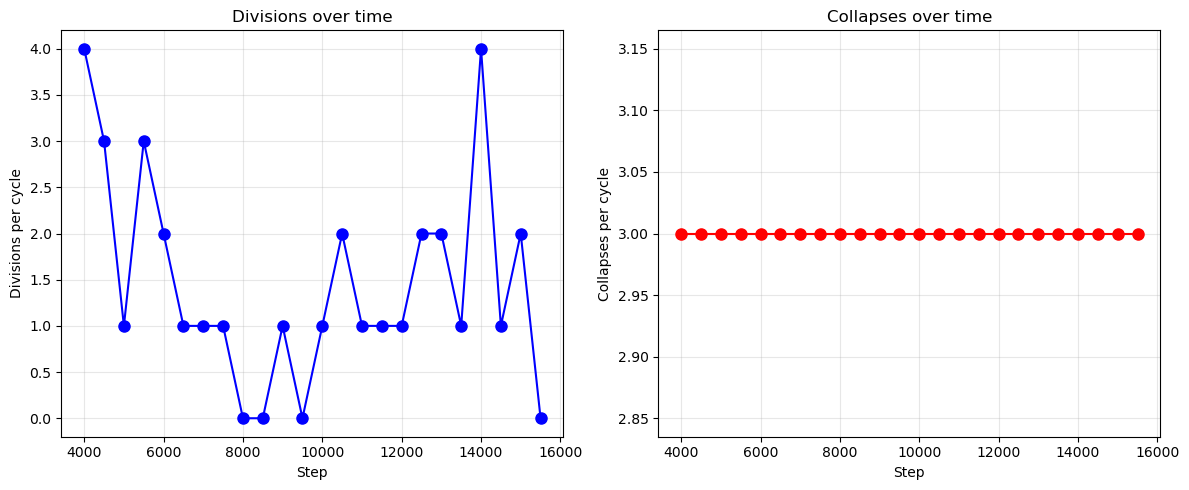

Visualization saved at step 15500
Final checkpoint saved to: ../../Figure_6_reviewed/with_apoptosis_0.0005/50_percent_line_tension_1.5_1_patches_seed_1_no_pressure_increase_sim_3/checkpoint_final.pkl


In [351]:
# ============================================================
# 2. CHECK COLUMNS EXIST (don't create them)
# ============================================================

v = cellmap.vert_df

# Verify columns exist
required_cols = ["new_vert_id", "parent_vert_id", "birth_step", "divided_step"]
for col in required_cols:
    if col not in v.columns:
        raise ValueError(f"Column '{col}' missing from vert_df — this should NOT happen!")

print("All tracking columns exist ✓")

# Get next available ID for new vertices
next_new_vert_id = int(v["new_vert_id"].max()) + 1
print(f"Next vertex ID: {next_new_vert_id}")

# Check current birth_step distribution
print(f"Vertices with birth_step == 0: {len(v[v['birth_step'] == 0])}")
print(f"Vertices with birth_step == 3500: {len(v[v['birth_step'] == 3500])}")

# ============================================================
# 3. SETUP PARAMETERS
# ============================================================

# Simulation parameters — continue from 3500
TOTAL_STEPS = 12000           # Total additional steps (3500 → 18500)
STEPS_PER_CYCLE = 500         # Save every 500 steps
RELAX_STEPS = 500             # Steps to relax after divisions

# Division parameters
EDGE_SUM_THRESHOLD = 3.5      # Changed back to original
DIVISION_DISTANCE = 0.01

# Collapse (apoptosis) parameters
COLLAPSE_FRACTION_PER_REMODEL = 0.0005  # 0.05% of inside edges per cycle
RELAX_AFTER_COLLAPSE = 10               # Relax steps after collapses

# Output directory
OUTPUT_DIR = "../../Figure_6_reviewed/with_apoptosis_0.0005/50_percent_line_tension_1.5_1_patches_seed_1_no_pressure_increase_sim_3"


# Starting step counter (continue from 3500)
STARTING_STEP = 3500

# ============================================================
# 4. DEFINE HELPER FUNCTIONS
# ============================================================

def relax(cellmap, nsteps: int):
    """Run mechanical relaxation without topological changes."""
    if nsteps <= 0:
        return cellmap
    energyContributions_model.compute_energy(cellmap)
    cellmap_out, _, _, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, int(nsteps)
    )
    return cellmap_out

def ensure_new_vert_ids(cellmap, next_id):
    """Assign unique IDs to any new vertices (from collapses etc)."""
    vdf = cellmap.vert_df
    if "new_vert_id" not in vdf.columns:
        vdf["new_vert_id"] = np.nan
    missing = vdf["new_vert_id"].isna()
    if missing.any():
        n = int(missing.sum())
        vdf.loc[missing, "new_vert_id"] = np.arange(next_id, next_id + n, dtype=int)
        next_id += n
    return next_id

def save_visualization_with_new_vertices(cellmap, geom, current_step, output_dir, divisions_count, collapses_count):
    """
    Create and save visualization with new vertices (birth_step == current_step) highlighted in red.
    """
    # Find vertices born at this step
    new_vert_ids = cellmap.vert_df[cellmap.vert_df["birth_step"] == current_step].index.tolist()
    
    fig, ax = plot_coloured_edges_with_new_vertices(
        cellmap,
        geom,
        new_vert_ids=new_vert_ids,
        col="line_tension",
        low_colour="mediumturquoise",
        high_colour="orange",
        threshold=155,
        width=3.0,
        show_axes=True,
        xlim=(-30, 70),
        ylim=(-30, 70),
        tick_spacing=10,
        new_vert_colour="red",
        new_vert_size=100,
        figsize=(10, 10),
        title=f"Step {current_step} | Div: {divisions_count} | Col: {collapses_count}",
        show_old_vertices=False,
    )
    
    plt.savefig(os.path.join(output_dir, f"progress_{current_step:06d}.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Visualization saved at step {current_step}")

# ============================================================
# 5. MAIN LOOP: EXPAND WITH DIVISIONS & COLLAPSES
# ============================================================

print(f"\n{'='*60}")
print(f"Continuing expansion from step {STARTING_STEP}")
print(f"Total additional steps: {TOTAL_STEPS} (to step {STARTING_STEP + TOTAL_STEPS})")
print(f"Saving every {STEPS_PER_CYCLE} steps")
print(f"{'='*60}\n")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Statistics
division_stats = []
collapse_stats = []

# Save initial state at step 3500
initial_step = STARTING_STEP
with open(os.path.join(OUTPUT_DIR, f"checkpoint_{initial_step:06d}.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Initial checkpoint saved at step {initial_step}")

# Save initial visualization using the new style
new_vert_ids_initial = cellmap.vert_df[cellmap.vert_df["birth_step"] == initial_step].index.tolist()
fig, ax = plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=new_vert_ids_initial,
    col="line_tension",
    low_colour="mediumturquoise",
    high_colour="orange",
    threshold=155,
    width=3.0,
    show_axes=True,
    xlim=(-30, 70),
    ylim=(-30, 70),
    tick_spacing=10,
    new_vert_colour="red",
    new_vert_size=100,
    figsize=(10, 10),
    title=f"Step {initial_step} | Starting point for expansion",
    show_old_vertices=False,
)
plt.savefig(os.path.join(OUTPUT_DIR, f"progress_{initial_step:06d}.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Initial visualization saved at step {initial_step}")

#cellmap.face_df['prefered_area'] *= 1.2

# Main expansion loop
for cycle in range(1, int(TOTAL_STEPS / STEPS_PER_CYCLE) + 1):
    current_step = STARTING_STEP + cycle * STEPS_PER_CYCLE
    print(f"\n{'='*60}")
    print(f"Cycle {cycle}: Step {current_step}")
    print(f"{'='*60}")

    # --------------------------------------------------------
    # Step 1: Identify inside vertices
    # --------------------------------------------------------
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 2: COLLAPSES (apoptosis)
    # --------------------------------------------------------
    current_collapses = 0
    
    # Identify inside edges
    valid_inside_edges = [e for e in inside_edges if e in cellmap.edge_df.index]
    n_inside = len(valid_inside_edges)
    target_collapse = int(np.floor(COLLAPSE_FRACTION_PER_REMODEL * n_inside))
    target_collapse = max(0, min(target_collapse, n_inside))
    
    if target_collapse > 0:
        edges_to_collapse = np.random.choice(valid_inside_edges, size=target_collapse, replace=False)
        for edge in edges_to_collapse:
            try:
                cellmap = collapse_single_edge(
                    cellmap, geom, energyContributions_model, edge
                )
                current_collapses += 1
            except Exception as e:
                print(f"  Warning: collapse failed for edge {edge}: {e}")
    
    print(f"  Collapses: {current_collapses}/{target_collapse}")
    
    # Reset indices after collapses
    cellmap.reset_index()
    cellmap.reset_topo()
    next_new_vert_id = ensure_new_vert_ids(cellmap, next_new_vert_id)
    
    # Relax after collapses
    if RELAX_AFTER_COLLAPSE > 0:
        cellmap = relax(cellmap, RELAX_AFTER_COLLAPSE)
        cellmap.reset_index()
        cellmap.reset_topo()
    
    # Re-identify boundaries after collapses
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 3: Perform divisions (using auxFunctionsExpansion.identify_vertices_to_divide)
    # --------------------------------------------------------
    vertices_to_divide = auxFunctionsExpansion.identify_vertices_to_divide(
        cellmap, inside_vertices, EDGE_SUM_THRESHOLD
    )
    
    print(f"  Found {len(vertices_to_divide)} vertices above threshold")

    current_divisions = 0

    if len(vertices_to_divide) > 0:
        divided_count = 0
        
        for v in vertices_to_divide:  # NO CAP — try ALL vertices
            try:
                cellmap, parent_vert, new_vert, new_edge, opp_edge = split_vertex(
                    cellmap, v, geom, energyContributions_model, DIVISION_DISTANCE, retry_attempts=3
                )
                
                if new_vert is not None:
                    # Record lineage with existing columns
                    parent_id = int(cellmap.vert_df.loc[parent_vert, "new_vert_id"])
                    cellmap.vert_df.loc[parent_vert, "divided_step"] = current_step
                    cellmap.vert_df.loc[new_vert, "new_vert_id"] = next_new_vert_id
                    cellmap.vert_df.loc[new_vert, "parent_vert_id"] = parent_id
                    cellmap.vert_df.loc[new_vert, "birth_step"] = current_step
                    next_new_vert_id += 1
                    divided_count += 1
                    
            except Exception as e:
                print(f"  Warning: division failed for vertex {v}: {e}")
        
        current_divisions = divided_count
        print(f"  Performed {current_divisions} divisions")

        cellmap.reset_index()
        cellmap.reset_topo()

    division_stats.append(current_divisions)
    collapse_stats.append(current_collapses)

    # --------------------------------------------------------
    # Step 4: Save post-division checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}_postdiv.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Post-division checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 5: Energy minimization / relaxation
    # --------------------------------------------------------
    print(f"  Relaxing for {RELAX_STEPS} steps...")
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, RELAX_STEPS
    )
    print(f"  Relaxation complete.")

    # --------------------------------------------------------
    # Step 6: Save checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 7: Save visualization
    # --------------------------------------------------------
    save_visualization_with_new_vertices(
        cellmap, 
        geom, 
        current_step, 
        OUTPUT_DIR, 
        current_divisions,
        current_collapses
    )

    # --------------------------------------------------------
    # Step 8: Update division stats
    # --------------------------------------------------------
    np.savetxt(os.path.join(OUTPUT_DIR, "division_stats.txt"), division_stats)
    np.savetxt(os.path.join(OUTPUT_DIR, "collapse_stats.txt"), collapse_stats)

# ============================================================
# 6. FINAL SUMMARY
# ============================================================

print(f"\n{'='*60}")
print("EXPANSION COMPLETE!")
print(f"Total divisions: {sum(division_stats)}")
print(f"Total collapses: {sum(collapse_stats)}")
print(f"Final vertex count: {len(cellmap.vert_df)}")
print(f"Final edge count: {len(cellmap.edge_df)}")
print(f"Output saved to: {OUTPUT_DIR}")
print(f"{'='*60}")
#
# Plot division and collapse statistics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

steps = [STARTING_STEP + i * STEPS_PER_CYCLE for i in range(1, len(division_stats) + 1)]

ax1.plot(steps, division_stats, 'bo-', markersize=8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Divisions per cycle')
ax1.set_title('Divisions over time')
ax1.grid(True, alpha=0.3)

ax2.plot(steps, collapse_stats, 'ro-', markersize=8)
ax2.set_xlabel('Step')
ax2.set_ylabel('Collapses per cycle')
ax2.set_title('Collapses over time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "division_collapse_stats.png"), dpi=150)
plt.show()

# Save final visualization
save_visualization_with_new_vertices(
    cellmap, 
    geom, 
    STARTING_STEP + TOTAL_STEPS, 
    OUTPUT_DIR, 
    division_stats[-1] if division_stats else 0,
    collapse_stats[-1] if collapse_stats else 0
)

# Save final cellmap
with open(os.path.join(OUTPUT_DIR, "checkpoint_final.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Final checkpoint saved to: {OUTPUT_DIR}/checkpoint_final.pkl")

In [352]:
with open(
    "../Simulations_with_remodelling_every_1000th_cycle/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_100_percent_div_3.5_3/checkpoint_003500.pkl",
    "rb"
) as f:
    cellmap = pickle.load(f)

In [353]:

#cellmap.edge_df['line_tension'] = 380*1.2

patches = make_patches(cellmap, n_patches=10, fraction=0.5, seed=1)
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=5, tension_col="length_elasticity")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=0.001, tension_col="prefered_length")
high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=1.5, tension_col="line_tension")


cellmap.reset_topo()



All tracking columns exist ✓
Next vertex ID: 2784
Vertices with birth_step == 0: 2742
Vertices with birth_step == 3500: 0

Continuing expansion from step 3500
Total additional steps: 12000 (to step 15500)
Saving every 500 steps

Initial checkpoint saved at step 3500
Initial visualization saved at step 3500

Cycle 1: Step 4000
Topology changed!
Topology changed!
Topology changed!
  Collapses: 3/3
Topology changed!
  Found 1 vertices above threshold
Open faces touching new vertex: [898.0, 934.0]
Topology changed!
 Successfully divided vertex 264.0 → new vertex 2753
  Performed 1 divisions
  Post-division checkpoint saved at step 4000
  Relaxing for 500 steps...
Topology changed!
  Relaxation complete.
  Checkpoint saved at step 4000
  ✓ Highlighted 1 new vertices in red
Visualization saved at step 4000

Cycle 2: Step 4500
Topology changed!
Topology changed!
Topology changed!
  Collapses: 3/3
Topology changed!
  Found 4 vertices above threshold
Open faces touching new vertex: [1233.0, 127

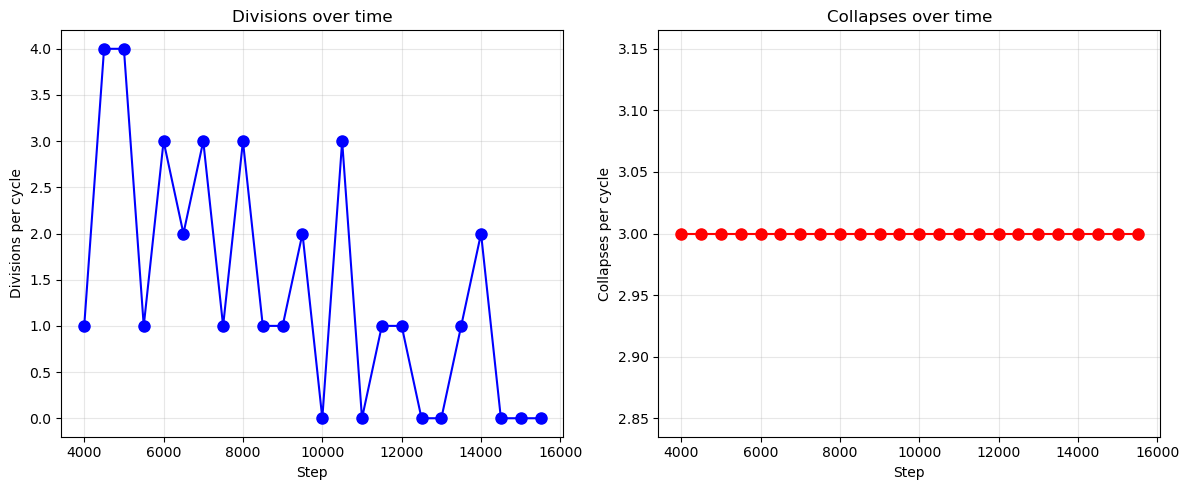

Visualization saved at step 15500
Final checkpoint saved to: ../../Figure_6_reviewed/with_apoptosis_0.0005/50_percent_line_tension_1.5_10_patches_seed_1_no_pressure_increase_sim_3/checkpoint_final.pkl


In [354]:
# ============================================================
# 2. CHECK COLUMNS EXIST (don't create them)
# ============================================================

v = cellmap.vert_df

# Verify columns exist
required_cols = ["new_vert_id", "parent_vert_id", "birth_step", "divided_step"]
for col in required_cols:
    if col not in v.columns:
        raise ValueError(f"Column '{col}' missing from vert_df — this should NOT happen!")

print("All tracking columns exist ✓")

# Get next available ID for new vertices
next_new_vert_id = int(v["new_vert_id"].max()) + 1
print(f"Next vertex ID: {next_new_vert_id}")

# Check current birth_step distribution
print(f"Vertices with birth_step == 0: {len(v[v['birth_step'] == 0])}")
print(f"Vertices with birth_step == 3500: {len(v[v['birth_step'] == 3500])}")

# ============================================================
# 3. SETUP PARAMETERS
# ============================================================

# Simulation parameters — continue from 3500
TOTAL_STEPS = 12000           # Total additional steps (3500 → 18500)
STEPS_PER_CYCLE = 500         # Save every 500 steps
RELAX_STEPS = 500             # Steps to relax after divisions

# Division parameters
EDGE_SUM_THRESHOLD = 3.5      # Changed back to original
DIVISION_DISTANCE = 0.01

# Collapse (apoptosis) parameters
COLLAPSE_FRACTION_PER_REMODEL = 0.0005  # 0.05% of inside edges per cycle
RELAX_AFTER_COLLAPSE = 10               # Relax steps after collapses

# Output directory
OUTPUT_DIR = "../../Figure_6_reviewed/with_apoptosis_0.0005/50_percent_line_tension_1.5_10_patches_seed_1_no_pressure_increase_sim_3"

# Starting step counter (continue from 3500)
STARTING_STEP = 3500

# ============================================================
# 4. DEFINE HELPER FUNCTIONS
# ============================================================

def relax(cellmap, nsteps: int):
    """Run mechanical relaxation without topological changes."""
    if nsteps <= 0:
        return cellmap
    energyContributions_model.compute_energy(cellmap)
    cellmap_out, _, _, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, int(nsteps)
    )
    return cellmap_out

def ensure_new_vert_ids(cellmap, next_id):
    """Assign unique IDs to any new vertices (from collapses etc)."""
    vdf = cellmap.vert_df
    if "new_vert_id" not in vdf.columns:
        vdf["new_vert_id"] = np.nan
    missing = vdf["new_vert_id"].isna()
    if missing.any():
        n = int(missing.sum())
        vdf.loc[missing, "new_vert_id"] = np.arange(next_id, next_id + n, dtype=int)
        next_id += n
    return next_id

def save_visualization_with_new_vertices(cellmap, geom, current_step, output_dir, divisions_count, collapses_count):
    """
    Create and save visualization with new vertices (birth_step == current_step) highlighted in red.
    """
    # Find vertices born at this step
    new_vert_ids = cellmap.vert_df[cellmap.vert_df["birth_step"] == current_step].index.tolist()
    
    fig, ax = plot_coloured_edges_with_new_vertices(
        cellmap,
        geom,
        new_vert_ids=new_vert_ids,
        col="line_tension",
        low_colour="mediumturquoise",
        high_colour="orange",
        threshold=155,
        width=3.0,
        show_axes=True,
        xlim=(-30, 70),
        ylim=(-30, 70),
        tick_spacing=10,
        new_vert_colour="red",
        new_vert_size=100,
        figsize=(10, 10),
        title=f"Step {current_step} | Div: {divisions_count} | Col: {collapses_count}",
        show_old_vertices=False,
    )
    
    plt.savefig(os.path.join(output_dir, f"progress_{current_step:06d}.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Visualization saved at step {current_step}")

# ============================================================
# 5. MAIN LOOP: EXPAND WITH DIVISIONS & COLLAPSES
# ============================================================

print(f"\n{'='*60}")
print(f"Continuing expansion from step {STARTING_STEP}")
print(f"Total additional steps: {TOTAL_STEPS} (to step {STARTING_STEP + TOTAL_STEPS})")
print(f"Saving every {STEPS_PER_CYCLE} steps")
print(f"{'='*60}\n")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Statistics
division_stats = []
collapse_stats = []

# Save initial state at step 3500
initial_step = STARTING_STEP
with open(os.path.join(OUTPUT_DIR, f"checkpoint_{initial_step:06d}.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Initial checkpoint saved at step {initial_step}")

# Save initial visualization using the new style
new_vert_ids_initial = cellmap.vert_df[cellmap.vert_df["birth_step"] == initial_step].index.tolist()
fig, ax = plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=new_vert_ids_initial,
    col="line_tension",
    low_colour="mediumturquoise",
    high_colour="orange",
    threshold=155,
    width=3.0,
    show_axes=True,
    xlim=(-30, 70),
    ylim=(-30, 70),
    tick_spacing=10,
    new_vert_colour="red",
    new_vert_size=100,
    figsize=(10, 10),
    title=f"Step {initial_step} | Starting point for expansion",
    show_old_vertices=False,
)
plt.savefig(os.path.join(OUTPUT_DIR, f"progress_{initial_step:06d}.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Initial visualization saved at step {initial_step}")

#cellmap.face_df['prefered_area'] *= 1.2

# Main expansion loop
for cycle in range(1, int(TOTAL_STEPS / STEPS_PER_CYCLE) + 1):
    current_step = STARTING_STEP + cycle * STEPS_PER_CYCLE
    print(f"\n{'='*60}")
    print(f"Cycle {cycle}: Step {current_step}")
    print(f"{'='*60}")

    # --------------------------------------------------------
    # Step 1: Identify inside vertices
    # --------------------------------------------------------
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 2: COLLAPSES (apoptosis)
    # --------------------------------------------------------
    current_collapses = 0
    
    # Identify inside edges
    valid_inside_edges = [e for e in inside_edges if e in cellmap.edge_df.index]
    n_inside = len(valid_inside_edges)
    target_collapse = int(np.floor(COLLAPSE_FRACTION_PER_REMODEL * n_inside))
    target_collapse = max(0, min(target_collapse, n_inside))
    
    if target_collapse > 0:
        edges_to_collapse = np.random.choice(valid_inside_edges, size=target_collapse, replace=False)
        for edge in edges_to_collapse:
            try:
                cellmap = collapse_single_edge(
                    cellmap, geom, energyContributions_model, edge
                )
                current_collapses += 1
            except Exception as e:
                print(f"  Warning: collapse failed for edge {edge}: {e}")
    
    print(f"  Collapses: {current_collapses}/{target_collapse}")
    
    # Reset indices after collapses
    cellmap.reset_index()
    cellmap.reset_topo()
    next_new_vert_id = ensure_new_vert_ids(cellmap, next_new_vert_id)
    
    # Relax after collapses
    if RELAX_AFTER_COLLAPSE > 0:
        cellmap = relax(cellmap, RELAX_AFTER_COLLAPSE)
        cellmap.reset_index()
        cellmap.reset_topo()
    
    # Re-identify boundaries after collapses
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 3: Perform divisions (using auxFunctionsExpansion.identify_vertices_to_divide)
    # --------------------------------------------------------
    vertices_to_divide = auxFunctionsExpansion.identify_vertices_to_divide(
        cellmap, inside_vertices, EDGE_SUM_THRESHOLD
    )
    
    print(f"  Found {len(vertices_to_divide)} vertices above threshold")

    current_divisions = 0

    if len(vertices_to_divide) > 0:
        divided_count = 0
        
        for v in vertices_to_divide:  # NO CAP — try ALL vertices
            try:
                cellmap, parent_vert, new_vert, new_edge, opp_edge = split_vertex(
                    cellmap, v, geom, energyContributions_model, DIVISION_DISTANCE, retry_attempts=3
                )
                
                if new_vert is not None:
                    # Record lineage with existing columns
                    parent_id = int(cellmap.vert_df.loc[parent_vert, "new_vert_id"])
                    cellmap.vert_df.loc[parent_vert, "divided_step"] = current_step
                    cellmap.vert_df.loc[new_vert, "new_vert_id"] = next_new_vert_id
                    cellmap.vert_df.loc[new_vert, "parent_vert_id"] = parent_id
                    cellmap.vert_df.loc[new_vert, "birth_step"] = current_step
                    next_new_vert_id += 1
                    divided_count += 1
                    
            except Exception as e:
                print(f"  Warning: division failed for vertex {v}: {e}")
        
        current_divisions = divided_count
        print(f"  Performed {current_divisions} divisions")

        cellmap.reset_index()
        cellmap.reset_topo()

    division_stats.append(current_divisions)
    collapse_stats.append(current_collapses)

    # --------------------------------------------------------
    # Step 4: Save post-division checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}_postdiv.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Post-division checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 5: Energy minimization / relaxation
    # --------------------------------------------------------
    print(f"  Relaxing for {RELAX_STEPS} steps...")
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, RELAX_STEPS
    )
    print(f"  Relaxation complete.")

    # --------------------------------------------------------
    # Step 6: Save checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 7: Save visualization
    # --------------------------------------------------------
    save_visualization_with_new_vertices(
        cellmap, 
        geom, 
        current_step, 
        OUTPUT_DIR, 
        current_divisions,
        current_collapses
    )

    # --------------------------------------------------------
    # Step 8: Update division stats
    # --------------------------------------------------------
    np.savetxt(os.path.join(OUTPUT_DIR, "division_stats.txt"), division_stats)
    np.savetxt(os.path.join(OUTPUT_DIR, "collapse_stats.txt"), collapse_stats)

# ============================================================
# 6. FINAL SUMMARY
# ============================================================

print(f"\n{'='*60}")
print("EXPANSION COMPLETE!")
print(f"Total divisions: {sum(division_stats)}")
print(f"Total collapses: {sum(collapse_stats)}")
print(f"Final vertex count: {len(cellmap.vert_df)}")
print(f"Final edge count: {len(cellmap.edge_df)}")
print(f"Output saved to: {OUTPUT_DIR}")
print(f"{'='*60}")
#
# Plot division and collapse statistics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

steps = [STARTING_STEP + i * STEPS_PER_CYCLE for i in range(1, len(division_stats) + 1)]

ax1.plot(steps, division_stats, 'bo-', markersize=8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Divisions per cycle')
ax1.set_title('Divisions over time')
ax1.grid(True, alpha=0.3)

ax2.plot(steps, collapse_stats, 'ro-', markersize=8)
ax2.set_xlabel('Step')
ax2.set_ylabel('Collapses per cycle')
ax2.set_title('Collapses over time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "division_collapse_stats.png"), dpi=150)
plt.show()

# Save final visualization
save_visualization_with_new_vertices(
    cellmap, 
    geom, 
    STARTING_STEP + TOTAL_STEPS, 
    OUTPUT_DIR, 
    division_stats[-1] if division_stats else 0,
    collapse_stats[-1] if collapse_stats else 0
)

# Save final cellmap
with open(os.path.join(OUTPUT_DIR, "checkpoint_final.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Final checkpoint saved to: {OUTPUT_DIR}/checkpoint_final.pkl")

In [358]:
with open(
    "../Simulations_with_remodelling_every_1000th_cycle/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_100_percent_div_3.5_3/checkpoint_003500.pkl",
    "rb"
) as f:
    cellmap = pickle.load(f)

In [359]:

#cellmap.edge_df['line_tension'] = 380*1.2

patches = make_patches(cellmap, n_patches=50, fraction=0.5, seed=1)
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=5, tension_col="length_elasticity")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=0.001, tension_col="prefered_length")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=1.5, tension_col="line_tension")


cellmap.reset_topo()


All tracking columns exist ✓
Next vertex ID: 2784
Vertices with birth_step == 0: 2742
Vertices with birth_step == 3500: 0

Continuing expansion from step 3500
Total additional steps: 12000 (to step 15500)
Saving every 500 steps

Initial checkpoint saved at step 3500
Initial visualization saved at step 3500

Cycle 1: Step 4000
Topology changed!
Topology changed!
Topology changed!
  Collapses: 3/3
Topology changed!
  Found 2 vertices above threshold
Open faces touching new vertex: [934.0, 935.0]
Topology changed!
 Successfully divided vertex 261.0 → new vertex 2753
Open faces touching new vertex: [32.0, 70.0]
Topology changed!
 Successfully divided vertex 2751.0 → new vertex 2754
  Performed 2 divisions
  Post-division checkpoint saved at step 4000
  Relaxing for 500 steps...
Topology changed!
  Relaxation complete.
  Checkpoint saved at step 4000
  ✓ Highlighted 2 new vertices in red
Visualization saved at step 4000

Cycle 2: Step 4500
Topology changed!
Topology changed!
Topology change

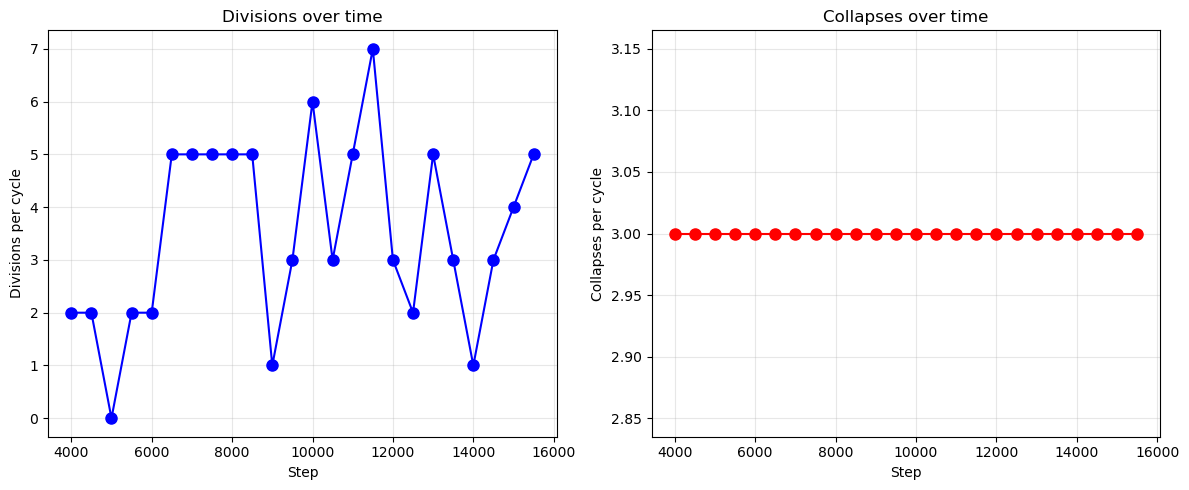

  ✓ Highlighted 5 new vertices in red
Visualization saved at step 15500
Final checkpoint saved to: ../../Figure_6_reviewed/with_apoptosis_0.0005/no_changes_to_stroma_expansion_no_pressure_increase_sim_3/checkpoint_final.pkl


In [360]:
# ============================================================
# 2. CHECK COLUMNS EXIST (don't create them)
# ============================================================

v = cellmap.vert_df

# Verify columns exist
required_cols = ["new_vert_id", "parent_vert_id", "birth_step", "divided_step"]
for col in required_cols:
    if col not in v.columns:
        raise ValueError(f"Column '{col}' missing from vert_df — this should NOT happen!")

print("All tracking columns exist ✓")

# Get next available ID for new vertices
next_new_vert_id = int(v["new_vert_id"].max()) + 1
print(f"Next vertex ID: {next_new_vert_id}")

# Check current birth_step distribution
print(f"Vertices with birth_step == 0: {len(v[v['birth_step'] == 0])}")
print(f"Vertices with birth_step == 3500: {len(v[v['birth_step'] == 3500])}")

# ============================================================
# 3. SETUP PARAMETERS
# ============================================================

# Simulation parameters — continue from 3500
TOTAL_STEPS = 12000           # Total additional steps (3500 → 18500)
STEPS_PER_CYCLE = 500         # Save every 500 steps
RELAX_STEPS = 500             # Steps to relax after divisions

# Division parameters
EDGE_SUM_THRESHOLD = 3.5      # Changed back to original
DIVISION_DISTANCE = 0.01

# Collapse (apoptosis) parameters
COLLAPSE_FRACTION_PER_REMODEL = 0.0005  # 0.05% of inside edges per cycle
RELAX_AFTER_COLLAPSE = 10               # Relax steps after collapses

# Output directory
OUTPUT_DIR = "../../Figure_6_reviewed/with_apoptosis_0.0005/no_changes_to_stroma_expansion_no_pressure_increase_sim_3"

# Starting step counter (continue from 3500)
STARTING_STEP = 3500

# ============================================================
# 4. DEFINE HELPER FUNCTIONS
# ============================================================

def relax(cellmap, nsteps: int):
    """Run mechanical relaxation without topological changes."""
    if nsteps <= 0:
        return cellmap
    energyContributions_model.compute_energy(cellmap)
    cellmap_out, _, _, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, int(nsteps)
    )
    return cellmap_out

def ensure_new_vert_ids(cellmap, next_id):
    """Assign unique IDs to any new vertices (from collapses etc)."""
    vdf = cellmap.vert_df
    if "new_vert_id" not in vdf.columns:
        vdf["new_vert_id"] = np.nan
    missing = vdf["new_vert_id"].isna()
    if missing.any():
        n = int(missing.sum())
        vdf.loc[missing, "new_vert_id"] = np.arange(next_id, next_id + n, dtype=int)
        next_id += n
    return next_id

def save_visualization_with_new_vertices(cellmap, geom, current_step, output_dir, divisions_count, collapses_count):
    """
    Create and save visualization with new vertices (birth_step == current_step) highlighted in red.
    """
    # Find vertices born at this step
    new_vert_ids = cellmap.vert_df[cellmap.vert_df["birth_step"] == current_step].index.tolist()
    
    fig, ax = plot_coloured_edges_with_new_vertices(
        cellmap,
        geom,
        new_vert_ids=new_vert_ids,
        col="line_tension",
        low_colour="mediumturquoise",
        high_colour="orange",
        threshold=155,
        width=3.0,
        show_axes=True,
        xlim=(-30, 70),
        ylim=(-30, 70),
        tick_spacing=10,
        new_vert_colour="red",
        new_vert_size=100,
        figsize=(10, 10),
        title=f"Step {current_step} | Div: {divisions_count} | Col: {collapses_count}",
        show_old_vertices=False,
    )
    
    plt.savefig(os.path.join(output_dir, f"progress_{current_step:06d}.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Visualization saved at step {current_step}")

# ============================================================
# 5. MAIN LOOP: EXPAND WITH DIVISIONS & COLLAPSES
# ============================================================

print(f"\n{'='*60}")
print(f"Continuing expansion from step {STARTING_STEP}")
print(f"Total additional steps: {TOTAL_STEPS} (to step {STARTING_STEP + TOTAL_STEPS})")
print(f"Saving every {STEPS_PER_CYCLE} steps")
print(f"{'='*60}\n")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Statistics
division_stats = []
collapse_stats = []

# Save initial state at step 3500
initial_step = STARTING_STEP
with open(os.path.join(OUTPUT_DIR, f"checkpoint_{initial_step:06d}.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Initial checkpoint saved at step {initial_step}")

# Save initial visualization using the new style
new_vert_ids_initial = cellmap.vert_df[cellmap.vert_df["birth_step"] == initial_step].index.tolist()
fig, ax = plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=new_vert_ids_initial,
    col="line_tension",
    low_colour="mediumturquoise",
    high_colour="orange",
    threshold=155,
    width=3.0,
    show_axes=True,
    xlim=(-30, 70),
    ylim=(-30, 70),
    tick_spacing=10,
    new_vert_colour="red",
    new_vert_size=100,
    figsize=(10, 10),
    title=f"Step {initial_step} | Starting point for expansion",
    show_old_vertices=False,
)
plt.savefig(os.path.join(OUTPUT_DIR, f"progress_{initial_step:06d}.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Initial visualization saved at step {initial_step}")

#cellmap.face_df['prefered_area'] *= 1.2

# Main expansion loop
for cycle in range(1, int(TOTAL_STEPS / STEPS_PER_CYCLE) + 1):
    current_step = STARTING_STEP + cycle * STEPS_PER_CYCLE
    print(f"\n{'='*60}")
    print(f"Cycle {cycle}: Step {current_step}")
    print(f"{'='*60}")

    # --------------------------------------------------------
    # Step 1: Identify inside vertices
    # --------------------------------------------------------
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 2: COLLAPSES (apoptosis)
    # --------------------------------------------------------
    current_collapses = 0
    
    # Identify inside edges
    valid_inside_edges = [e for e in inside_edges if e in cellmap.edge_df.index]
    n_inside = len(valid_inside_edges)
    target_collapse = int(np.floor(COLLAPSE_FRACTION_PER_REMODEL * n_inside))
    target_collapse = max(0, min(target_collapse, n_inside))
    
    if target_collapse > 0:
        edges_to_collapse = np.random.choice(valid_inside_edges, size=target_collapse, replace=False)
        for edge in edges_to_collapse:
            try:
                cellmap = collapse_single_edge(
                    cellmap, geom, energyContributions_model, edge
                )
                current_collapses += 1
            except Exception as e:
                print(f"  Warning: collapse failed for edge {edge}: {e}")
    
    print(f"  Collapses: {current_collapses}/{target_collapse}")
    
    # Reset indices after collapses
    cellmap.reset_index()
    cellmap.reset_topo()
    next_new_vert_id = ensure_new_vert_ids(cellmap, next_new_vert_id)
    
    # Relax after collapses
    if RELAX_AFTER_COLLAPSE > 0:
        cellmap = relax(cellmap, RELAX_AFTER_COLLAPSE)
        cellmap.reset_index()
        cellmap.reset_topo()
    
    # Re-identify boundaries after collapses
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 3: Perform divisions (using auxFunctionsExpansion.identify_vertices_to_divide)
    # --------------------------------------------------------
    vertices_to_divide = auxFunctionsExpansion.identify_vertices_to_divide(
        cellmap, inside_vertices, EDGE_SUM_THRESHOLD
    )
    
    print(f"  Found {len(vertices_to_divide)} vertices above threshold")

    current_divisions = 0

    if len(vertices_to_divide) > 0:
        divided_count = 0
        
        for v in vertices_to_divide:  # NO CAP — try ALL vertices
            try:
                cellmap, parent_vert, new_vert, new_edge, opp_edge = split_vertex(
                    cellmap, v, geom, energyContributions_model, DIVISION_DISTANCE, retry_attempts=3
                )
                
                if new_vert is not None:
                    # Record lineage with existing columns
                    parent_id = int(cellmap.vert_df.loc[parent_vert, "new_vert_id"])
                    cellmap.vert_df.loc[parent_vert, "divided_step"] = current_step
                    cellmap.vert_df.loc[new_vert, "new_vert_id"] = next_new_vert_id
                    cellmap.vert_df.loc[new_vert, "parent_vert_id"] = parent_id
                    cellmap.vert_df.loc[new_vert, "birth_step"] = current_step
                    next_new_vert_id += 1
                    divided_count += 1
                    
            except Exception as e:
                print(f"  Warning: division failed for vertex {v}: {e}")
        
        current_divisions = divided_count
        print(f"  Performed {current_divisions} divisions")

        cellmap.reset_index()
        cellmap.reset_topo()

    division_stats.append(current_divisions)
    collapse_stats.append(current_collapses)

    # --------------------------------------------------------
    # Step 4: Save post-division checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}_postdiv.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Post-division checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 5: Energy minimization / relaxation
    # --------------------------------------------------------
    print(f"  Relaxing for {RELAX_STEPS} steps...")
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, RELAX_STEPS
    )
    print(f"  Relaxation complete.")

    # --------------------------------------------------------
    # Step 6: Save checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 7: Save visualization
    # --------------------------------------------------------
    save_visualization_with_new_vertices(
        cellmap, 
        geom, 
        current_step, 
        OUTPUT_DIR, 
        current_divisions,
        current_collapses
    )

    # --------------------------------------------------------
    # Step 8: Update division stats
    # --------------------------------------------------------
    np.savetxt(os.path.join(OUTPUT_DIR, "division_stats.txt"), division_stats)
    np.savetxt(os.path.join(OUTPUT_DIR, "collapse_stats.txt"), collapse_stats)

# ============================================================
# 6. FINAL SUMMARY
# ============================================================

print(f"\n{'='*60}")
print("EXPANSION COMPLETE!")
print(f"Total divisions: {sum(division_stats)}")
print(f"Total collapses: {sum(collapse_stats)}")
print(f"Final vertex count: {len(cellmap.vert_df)}")
print(f"Final edge count: {len(cellmap.edge_df)}")
print(f"Output saved to: {OUTPUT_DIR}")
print(f"{'='*60}")
#
# Plot division and collapse statistics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

steps = [STARTING_STEP + i * STEPS_PER_CYCLE for i in range(1, len(division_stats) + 1)]

ax1.plot(steps, division_stats, 'bo-', markersize=8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Divisions per cycle')
ax1.set_title('Divisions over time')
ax1.grid(True, alpha=0.3)

ax2.plot(steps, collapse_stats, 'ro-', markersize=8)
ax2.set_xlabel('Step')
ax2.set_ylabel('Collapses per cycle')
ax2.set_title('Collapses over time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "division_collapse_stats.png"), dpi=150)
plt.show()

# Save final visualization
save_visualization_with_new_vertices(
    cellmap, 
    geom, 
    STARTING_STEP + TOTAL_STEPS, 
    OUTPUT_DIR, 
    division_stats[-1] if division_stats else 0,
    collapse_stats[-1] if collapse_stats else 0
)

# Save final cellmap
with open(os.path.join(OUTPUT_DIR, "checkpoint_final.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Final checkpoint saved to: {OUTPUT_DIR}/checkpoint_final.pkl")

In [331]:
with open(
    "../Simulations_with_remodelling_every_1000th_cycle/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_100_percent_div_3.5_3/checkpoint_003500.pkl",
    "rb"
) as f:
    cellmap = pickle.load(f)

In [332]:

#cellmap.edge_df['line_tension'] = 380*1.2

patches = make_patches(cellmap, n_patches=1, fraction=0.3, seed=1)
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=3, tension_col="length_elasticity")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=0.001, tension_col="prefered_length")
high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=1.5, tension_col="line_tension")


cellmap.reset_topo()

All tracking columns exist ✓
Next vertex ID: 2784
Vertices with birth_step == 0: 2742
Vertices with birth_step == 3500: 0

Continuing expansion from step 3500
Total additional steps: 12000 (to step 15500)
Saving every 500 steps

Initial checkpoint saved at step 3500
Initial visualization saved at step 3500

Cycle 1: Step 4000
Topology changed!
Topology changed!
Topology changed!
  Collapses: 3/3
Topology changed!
  Found 2 vertices above threshold
Open faces touching new vertex: [898.0, 935.0]
Topology changed!
 Successfully divided vertex 264.0 → new vertex 2753
Open faces touching new vertex: [400.0, 476.0]
Topology changed!
 Successfully divided vertex 2751.0 → new vertex 2754
  Performed 2 divisions
  Post-division checkpoint saved at step 4000
  Relaxing for 500 steps...
Topology changed!
  Relaxation complete.
  Checkpoint saved at step 4000
  ✓ Highlighted 2 new vertices in red
Visualization saved at step 4000

Cycle 2: Step 4500
Topology changed!
Topology changed!
Topology chan

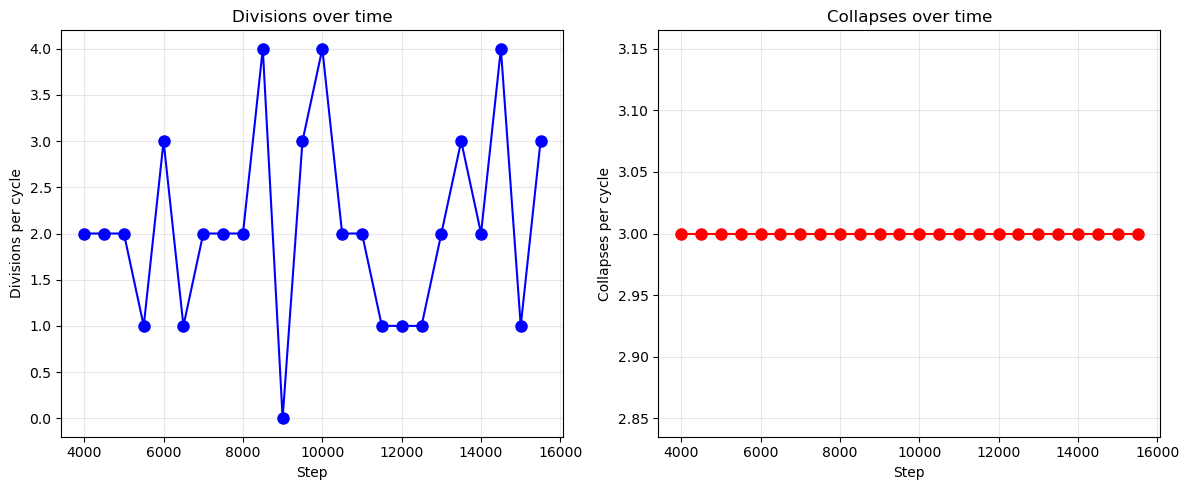

  ✓ Highlighted 3 new vertices in red
Visualization saved at step 15500
Final checkpoint saved to: ../../Figure_6_reviewed/with_apoptosis_0.0005/30_percent_line_tension_1.5_1_patches_seed_1_no_pressure_increase_sim_3/checkpoint_final.pkl


In [333]:
# ============================================================
# 2. CHECK COLUMNS EXIST (don't create them)
# ============================================================

v = cellmap.vert_df

# Verify columns exist
required_cols = ["new_vert_id", "parent_vert_id", "birth_step", "divided_step"]
for col in required_cols:
    if col not in v.columns:
        raise ValueError(f"Column '{col}' missing from vert_df — this should NOT happen!")

print("All tracking columns exist ✓")

# Get next available ID for new vertices
next_new_vert_id = int(v["new_vert_id"].max()) + 1
print(f"Next vertex ID: {next_new_vert_id}")

# Check current birth_step distribution
print(f"Vertices with birth_step == 0: {len(v[v['birth_step'] == 0])}")
print(f"Vertices with birth_step == 3500: {len(v[v['birth_step'] == 3500])}")

# ============================================================
# 3. SETUP PARAMETERS
# ============================================================

# Simulation parameters — continue from 3500
TOTAL_STEPS = 12000           # Total additional steps (3500 → 18500)
STEPS_PER_CYCLE = 500         # Save every 500 steps
RELAX_STEPS = 500             # Steps to relax after divisions

# Division parameters
EDGE_SUM_THRESHOLD = 3.5      # Changed back to original
DIVISION_DISTANCE = 0.01

# Collapse (apoptosis) parameters
COLLAPSE_FRACTION_PER_REMODEL = 0.0005  # 0.05% of inside edges per cycle
RELAX_AFTER_COLLAPSE = 10               # Relax steps after collapses

# Output directory
OUTPUT_DIR = "../../Figure_6_reviewed/with_apoptosis_0.0005/30_percent_line_tension_1.5_1_patches_seed_1_no_pressure_increase_sim_3"

# Starting step counter (continue from 3500)
STARTING_STEP = 3500

# ============================================================
# 4. DEFINE HELPER FUNCTIONS
# ============================================================

def relax(cellmap, nsteps: int):
    """Run mechanical relaxation without topological changes."""
    if nsteps <= 0:
        return cellmap
    energyContributions_model.compute_energy(cellmap)
    cellmap_out, _, _, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, int(nsteps)
    )
    return cellmap_out

def ensure_new_vert_ids(cellmap, next_id):
    """Assign unique IDs to any new vertices (from collapses etc)."""
    vdf = cellmap.vert_df
    if "new_vert_id" not in vdf.columns:
        vdf["new_vert_id"] = np.nan
    missing = vdf["new_vert_id"].isna()
    if missing.any():
        n = int(missing.sum())
        vdf.loc[missing, "new_vert_id"] = np.arange(next_id, next_id + n, dtype=int)
        next_id += n
    return next_id

def save_visualization_with_new_vertices(cellmap, geom, current_step, output_dir, divisions_count, collapses_count):
    """
    Create and save visualization with new vertices (birth_step == current_step) highlighted in red.
    """
    # Find vertices born at this step
    new_vert_ids = cellmap.vert_df[cellmap.vert_df["birth_step"] == current_step].index.tolist()
    
    fig, ax = plot_coloured_edges_with_new_vertices(
        cellmap,
        geom,
        new_vert_ids=new_vert_ids,
        col="line_tension",
        low_colour="mediumturquoise",
        high_colour="orange",
        threshold=155,
        width=3.0,
        show_axes=True,
        xlim=(-30, 70),
        ylim=(-30, 70),
        tick_spacing=10,
        new_vert_colour="red",
        new_vert_size=100,
        figsize=(10, 10),
        title=f"Step {current_step} | Div: {divisions_count} | Col: {collapses_count}",
        show_old_vertices=False,
    )
    
    plt.savefig(os.path.join(output_dir, f"progress_{current_step:06d}.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Visualization saved at step {current_step}")

# ============================================================
# 5. MAIN LOOP: EXPAND WITH DIVISIONS & COLLAPSES
# ============================================================

print(f"\n{'='*60}")
print(f"Continuing expansion from step {STARTING_STEP}")
print(f"Total additional steps: {TOTAL_STEPS} (to step {STARTING_STEP + TOTAL_STEPS})")
print(f"Saving every {STEPS_PER_CYCLE} steps")
print(f"{'='*60}\n")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Statistics
division_stats = []
collapse_stats = []

# Save initial state at step 3500
initial_step = STARTING_STEP
with open(os.path.join(OUTPUT_DIR, f"checkpoint_{initial_step:06d}.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Initial checkpoint saved at step {initial_step}")

# Save initial visualization using the new style
new_vert_ids_initial = cellmap.vert_df[cellmap.vert_df["birth_step"] == initial_step].index.tolist()
fig, ax = plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=new_vert_ids_initial,
    col="line_tension",
    low_colour="mediumturquoise",
    high_colour="orange",
    threshold=155,
    width=3.0,
    show_axes=True,
    xlim=(-30, 70),
    ylim=(-30, 70),
    tick_spacing=10,
    new_vert_colour="red",
    new_vert_size=100,
    figsize=(10, 10),
    title=f"Step {initial_step} | Starting point for expansion",
    show_old_vertices=False,
)
plt.savefig(os.path.join(OUTPUT_DIR, f"progress_{initial_step:06d}.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Initial visualization saved at step {initial_step}")

#cellmap.face_df['prefered_area'] *= 1.2

# Main expansion loop
for cycle in range(1, int(TOTAL_STEPS / STEPS_PER_CYCLE) + 1):
    current_step = STARTING_STEP + cycle * STEPS_PER_CYCLE
    print(f"\n{'='*60}")
    print(f"Cycle {cycle}: Step {current_step}")
    print(f"{'='*60}")

    # --------------------------------------------------------
    # Step 1: Identify inside vertices
    # --------------------------------------------------------
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 2: COLLAPSES (apoptosis)
    # --------------------------------------------------------
    current_collapses = 0
    
    # Identify inside edges
    valid_inside_edges = [e for e in inside_edges if e in cellmap.edge_df.index]
    n_inside = len(valid_inside_edges)
    target_collapse = int(np.floor(COLLAPSE_FRACTION_PER_REMODEL * n_inside))
    target_collapse = max(0, min(target_collapse, n_inside))
    
    if target_collapse > 0:
        edges_to_collapse = np.random.choice(valid_inside_edges, size=target_collapse, replace=False)
        for edge in edges_to_collapse:
            try:
                cellmap = collapse_single_edge(
                    cellmap, geom, energyContributions_model, edge
                )
                current_collapses += 1
            except Exception as e:
                print(f"  Warning: collapse failed for edge {edge}: {e}")
    
    print(f"  Collapses: {current_collapses}/{target_collapse}")
    
    # Reset indices after collapses
    cellmap.reset_index()
    cellmap.reset_topo()
    next_new_vert_id = ensure_new_vert_ids(cellmap, next_new_vert_id)
    
    # Relax after collapses
    if RELAX_AFTER_COLLAPSE > 0:
        cellmap = relax(cellmap, RELAX_AFTER_COLLAPSE)
        cellmap.reset_index()
        cellmap.reset_topo()
    
    # Re-identify boundaries after collapses
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 3: Perform divisions (using auxFunctionsExpansion.identify_vertices_to_divide)
    # --------------------------------------------------------
    vertices_to_divide = auxFunctionsExpansion.identify_vertices_to_divide(
        cellmap, inside_vertices, EDGE_SUM_THRESHOLD
    )
    
    print(f"  Found {len(vertices_to_divide)} vertices above threshold")

    current_divisions = 0

    if len(vertices_to_divide) > 0:
        divided_count = 0
        
        for v in vertices_to_divide:  # NO CAP — try ALL vertices
            try:
                cellmap, parent_vert, new_vert, new_edge, opp_edge = split_vertex(
                    cellmap, v, geom, energyContributions_model, DIVISION_DISTANCE, retry_attempts=3
                )
                
                if new_vert is not None:
                    # Record lineage with existing columns
                    parent_id = int(cellmap.vert_df.loc[parent_vert, "new_vert_id"])
                    cellmap.vert_df.loc[parent_vert, "divided_step"] = current_step
                    cellmap.vert_df.loc[new_vert, "new_vert_id"] = next_new_vert_id
                    cellmap.vert_df.loc[new_vert, "parent_vert_id"] = parent_id
                    cellmap.vert_df.loc[new_vert, "birth_step"] = current_step
                    next_new_vert_id += 1
                    divided_count += 1
                    
            except Exception as e:
                print(f"  Warning: division failed for vertex {v}: {e}")
        
        current_divisions = divided_count
        print(f"  Performed {current_divisions} divisions")

        cellmap.reset_index()
        cellmap.reset_topo()

    division_stats.append(current_divisions)
    collapse_stats.append(current_collapses)

    # --------------------------------------------------------
    # Step 4: Save post-division checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}_postdiv.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Post-division checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 5: Energy minimization / relaxation
    # --------------------------------------------------------
    print(f"  Relaxing for {RELAX_STEPS} steps...")
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, RELAX_STEPS
    )
    print(f"  Relaxation complete.")

    # --------------------------------------------------------
    # Step 6: Save checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 7: Save visualization
    # --------------------------------------------------------
    save_visualization_with_new_vertices(
        cellmap, 
        geom, 
        current_step, 
        OUTPUT_DIR, 
        current_divisions,
        current_collapses
    )

    # --------------------------------------------------------
    # Step 8: Update division stats
    # --------------------------------------------------------
    np.savetxt(os.path.join(OUTPUT_DIR, "division_stats.txt"), division_stats)
    np.savetxt(os.path.join(OUTPUT_DIR, "collapse_stats.txt"), collapse_stats)

# ============================================================
# 6. FINAL SUMMARY
# ============================================================

print(f"\n{'='*60}")
print("EXPANSION COMPLETE!")
print(f"Total divisions: {sum(division_stats)}")
print(f"Total collapses: {sum(collapse_stats)}")
print(f"Final vertex count: {len(cellmap.vert_df)}")
print(f"Final edge count: {len(cellmap.edge_df)}")
print(f"Output saved to: {OUTPUT_DIR}")
print(f"{'='*60}")
#
# Plot division and collapse statistics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

steps = [STARTING_STEP + i * STEPS_PER_CYCLE for i in range(1, len(division_stats) + 1)]

ax1.plot(steps, division_stats, 'bo-', markersize=8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Divisions per cycle')
ax1.set_title('Divisions over time')
ax1.grid(True, alpha=0.3)

ax2.plot(steps, collapse_stats, 'ro-', markersize=8)
ax2.set_xlabel('Step')
ax2.set_ylabel('Collapses per cycle')
ax2.set_title('Collapses over time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "division_collapse_stats.png"), dpi=150)
plt.show()

# Save final visualization
save_visualization_with_new_vertices(
    cellmap, 
    geom, 
    STARTING_STEP + TOTAL_STEPS, 
    OUTPUT_DIR, 
    division_stats[-1] if division_stats else 0,
    collapse_stats[-1] if collapse_stats else 0
)

# Save final cellmap
with open(os.path.join(OUTPUT_DIR, "checkpoint_final.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Final checkpoint saved to: {OUTPUT_DIR}/checkpoint_final.pkl")

In [334]:
with open(
    "../Simulations_with_remodelling_every_1000th_cycle/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_100_percent_div_3.5_3/checkpoint_003500.pkl",
    "rb"
) as f:
    cellmap = pickle.load(f)

In [335]:

#cellmap.edge_df['line_tension'] = 380*1.2

patches = make_patches(cellmap, n_patches=10, fraction=0.3, seed=1)
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=3, tension_col="length_elasticity")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=0.001, tension_col="prefered_length")
high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=1.5, tension_col="line_tension")


cellmap.reset_topo()

All tracking columns exist ✓
Next vertex ID: 2784
Vertices with birth_step == 0: 2742
Vertices with birth_step == 3500: 0

Continuing expansion from step 3500
Total additional steps: 12000 (to step 15500)
Saving every 500 steps

Initial checkpoint saved at step 3500
Initial visualization saved at step 3500

Cycle 1: Step 4000
Topology changed!
Topology changed!
Topology changed!
  Collapses: 3/3
Topology changed!
  Found 3 vertices above threshold
Open faces touching new vertex: [898.0, 935.0]
Topology changed!
 Successfully divided vertex 264.0 → new vertex 2753
Open faces touching new vertex: [1205.0, 1242.0]
Topology changed!
 Successfully divided vertex 2751.0 → new vertex 2754
Open faces touching new vertex: [614.0, 688.0]
Topology changed!
 Successfully divided vertex 2752.0 → new vertex 2755
  Performed 3 divisions
  Post-division checkpoint saved at step 4000
  Relaxing for 500 steps...
Topology changed!
  Relaxation complete.
  Checkpoint saved at step 4000
  ✓ Highlighted 3 n

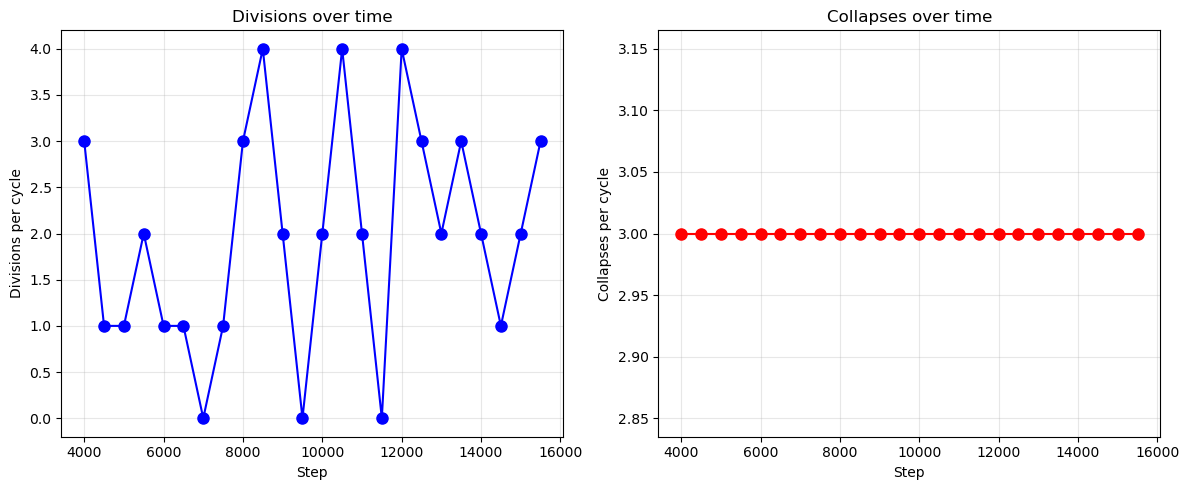

  ✓ Highlighted 3 new vertices in red
Visualization saved at step 15500
Final checkpoint saved to: ../../Figure_6_reviewed/with_apoptosis_0.0005/30_percent_line_tension_1.5_10_patches_seed_1_no_pressure_increase_3.5_div_sim_3/checkpoint_final.pkl


In [336]:
# ============================================================
# 2. CHECK COLUMNS EXIST (don't create them)
# ============================================================

v = cellmap.vert_df

# Verify columns exist
required_cols = ["new_vert_id", "parent_vert_id", "birth_step", "divided_step"]
for col in required_cols:
    if col not in v.columns:
        raise ValueError(f"Column '{col}' missing from vert_df — this should NOT happen!")

print("All tracking columns exist ✓")

# Get next available ID for new vertices
next_new_vert_id = int(v["new_vert_id"].max()) + 1
print(f"Next vertex ID: {next_new_vert_id}")

# Check current birth_step distribution
print(f"Vertices with birth_step == 0: {len(v[v['birth_step'] == 0])}")
print(f"Vertices with birth_step == 3500: {len(v[v['birth_step'] == 3500])}")

# ============================================================
# 3. SETUP PARAMETERS
# ============================================================

# Simulation parameters — continue from 3500
TOTAL_STEPS = 12000           # Total additional steps (3500 → 18500)
STEPS_PER_CYCLE = 500         # Save every 500 steps
RELAX_STEPS = 500             # Steps to relax after divisions

# Division parameters
EDGE_SUM_THRESHOLD = 3.5      # Changed back to original
DIVISION_DISTANCE = 0.01

# Collapse (apoptosis) parameters
COLLAPSE_FRACTION_PER_REMODEL = 0.0005  # 0.05% of inside edges per cycle
RELAX_AFTER_COLLAPSE = 10               # Relax steps after collapses

# Output directory
OUTPUT_DIR = "../../Figure_6_reviewed/with_apoptosis_0.0005/30_percent_line_tension_1.5_10_patches_seed_1_no_pressure_increase_3.5_div_sim_3"

# Starting step counter (continue from 3500)
STARTING_STEP = 3500

# ============================================================
# 4. DEFINE HELPER FUNCTIONS
# ============================================================

def relax(cellmap, nsteps: int):
    """Run mechanical relaxation without topological changes."""
    if nsteps <= 0:
        return cellmap
    energyContributions_model.compute_energy(cellmap)
    cellmap_out, _, _, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, int(nsteps)
    )
    return cellmap_out

def ensure_new_vert_ids(cellmap, next_id):
    """Assign unique IDs to any new vertices (from collapses etc)."""
    vdf = cellmap.vert_df
    if "new_vert_id" not in vdf.columns:
        vdf["new_vert_id"] = np.nan
    missing = vdf["new_vert_id"].isna()
    if missing.any():
        n = int(missing.sum())
        vdf.loc[missing, "new_vert_id"] = np.arange(next_id, next_id + n, dtype=int)
        next_id += n
    return next_id

def save_visualization_with_new_vertices(cellmap, geom, current_step, output_dir, divisions_count, collapses_count):
    """
    Create and save visualization with new vertices (birth_step == current_step) highlighted in red.
    """
    # Find vertices born at this step
    new_vert_ids = cellmap.vert_df[cellmap.vert_df["birth_step"] == current_step].index.tolist()
    
    fig, ax = plot_coloured_edges_with_new_vertices(
        cellmap,
        geom,
        new_vert_ids=new_vert_ids,
        col="line_tension",
        low_colour="mediumturquoise",
        high_colour="orange",
        threshold=155,
        width=3.0,
        show_axes=True,
        xlim=(-30, 70),
        ylim=(-30, 70),
        tick_spacing=10,
        new_vert_colour="red",
        new_vert_size=100,
        figsize=(10, 10),
        title=f"Step {current_step} | Div: {divisions_count} | Col: {collapses_count}",
        show_old_vertices=False,
    )
    
    plt.savefig(os.path.join(output_dir, f"progress_{current_step:06d}.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Visualization saved at step {current_step}")

# ============================================================
# 5. MAIN LOOP: EXPAND WITH DIVISIONS & COLLAPSES
# ============================================================

print(f"\n{'='*60}")
print(f"Continuing expansion from step {STARTING_STEP}")
print(f"Total additional steps: {TOTAL_STEPS} (to step {STARTING_STEP + TOTAL_STEPS})")
print(f"Saving every {STEPS_PER_CYCLE} steps")
print(f"{'='*60}\n")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Statistics
division_stats = []
collapse_stats = []

# Save initial state at step 3500
initial_step = STARTING_STEP
with open(os.path.join(OUTPUT_DIR, f"checkpoint_{initial_step:06d}.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Initial checkpoint saved at step {initial_step}")

# Save initial visualization using the new style
new_vert_ids_initial = cellmap.vert_df[cellmap.vert_df["birth_step"] == initial_step].index.tolist()
fig, ax = plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=new_vert_ids_initial,
    col="line_tension",
    low_colour="mediumturquoise",
    high_colour="orange",
    threshold=155,
    width=3.0,
    show_axes=True,
    xlim=(-30, 70),
    ylim=(-30, 70),
    tick_spacing=10,
    new_vert_colour="red",
    new_vert_size=100,
    figsize=(10, 10),
    title=f"Step {initial_step} | Starting point for expansion",
    show_old_vertices=False,
)
plt.savefig(os.path.join(OUTPUT_DIR, f"progress_{initial_step:06d}.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Initial visualization saved at step {initial_step}")

#cellmap.face_df['prefered_area'] *= 1.2

# Main expansion loop
for cycle in range(1, int(TOTAL_STEPS / STEPS_PER_CYCLE) + 1):
    current_step = STARTING_STEP + cycle * STEPS_PER_CYCLE
    print(f"\n{'='*60}")
    print(f"Cycle {cycle}: Step {current_step}")
    print(f"{'='*60}")

    # --------------------------------------------------------
    # Step 1: Identify inside vertices
    # --------------------------------------------------------
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 2: COLLAPSES (apoptosis)
    # --------------------------------------------------------
    current_collapses = 0
    
    # Identify inside edges
    valid_inside_edges = [e for e in inside_edges if e in cellmap.edge_df.index]
    n_inside = len(valid_inside_edges)
    target_collapse = int(np.floor(COLLAPSE_FRACTION_PER_REMODEL * n_inside))
    target_collapse = max(0, min(target_collapse, n_inside))
    
    if target_collapse > 0:
        edges_to_collapse = np.random.choice(valid_inside_edges, size=target_collapse, replace=False)
        for edge in edges_to_collapse:
            try:
                cellmap = collapse_single_edge(
                    cellmap, geom, energyContributions_model, edge
                )
                current_collapses += 1
            except Exception as e:
                print(f"  Warning: collapse failed for edge {edge}: {e}")
    
    print(f"  Collapses: {current_collapses}/{target_collapse}")
    
    # Reset indices after collapses
    cellmap.reset_index()
    cellmap.reset_topo()
    next_new_vert_id = ensure_new_vert_ids(cellmap, next_new_vert_id)
    
    # Relax after collapses
    if RELAX_AFTER_COLLAPSE > 0:
        cellmap = relax(cellmap, RELAX_AFTER_COLLAPSE)
        cellmap.reset_index()
        cellmap.reset_topo()
    
    # Re-identify boundaries after collapses
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 3: Perform divisions (using auxFunctionsExpansion.identify_vertices_to_divide)
    # --------------------------------------------------------
    vertices_to_divide = auxFunctionsExpansion.identify_vertices_to_divide(
        cellmap, inside_vertices, EDGE_SUM_THRESHOLD
    )
    
    print(f"  Found {len(vertices_to_divide)} vertices above threshold")

    current_divisions = 0

    if len(vertices_to_divide) > 0:
        divided_count = 0
        
        for v in vertices_to_divide:  # NO CAP — try ALL vertices
            try:
                cellmap, parent_vert, new_vert, new_edge, opp_edge = split_vertex(
                    cellmap, v, geom, energyContributions_model, DIVISION_DISTANCE, retry_attempts=3
                )
                
                if new_vert is not None:
                    # Record lineage with existing columns
                    parent_id = int(cellmap.vert_df.loc[parent_vert, "new_vert_id"])
                    cellmap.vert_df.loc[parent_vert, "divided_step"] = current_step
                    cellmap.vert_df.loc[new_vert, "new_vert_id"] = next_new_vert_id
                    cellmap.vert_df.loc[new_vert, "parent_vert_id"] = parent_id
                    cellmap.vert_df.loc[new_vert, "birth_step"] = current_step
                    next_new_vert_id += 1
                    divided_count += 1
                    
            except Exception as e:
                print(f"  Warning: division failed for vertex {v}: {e}")
        
        current_divisions = divided_count
        print(f"  Performed {current_divisions} divisions")

        cellmap.reset_index()
        cellmap.reset_topo()

    division_stats.append(current_divisions)
    collapse_stats.append(current_collapses)

    # --------------------------------------------------------
    # Step 4: Save post-division checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}_postdiv.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Post-division checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 5: Energy minimization / relaxation
    # --------------------------------------------------------
    print(f"  Relaxing for {RELAX_STEPS} steps...")
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, RELAX_STEPS
    )
    print(f"  Relaxation complete.")

    # --------------------------------------------------------
    # Step 6: Save checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 7: Save visualization
    # --------------------------------------------------------
    save_visualization_with_new_vertices(
        cellmap, 
        geom, 
        current_step, 
        OUTPUT_DIR, 
        current_divisions,
        current_collapses
    )

    # --------------------------------------------------------
    # Step 8: Update division stats
    # --------------------------------------------------------
    np.savetxt(os.path.join(OUTPUT_DIR, "division_stats.txt"), division_stats)
    np.savetxt(os.path.join(OUTPUT_DIR, "collapse_stats.txt"), collapse_stats)

# ============================================================
# 6. FINAL SUMMARY
# ============================================================

print(f"\n{'='*60}")
print("EXPANSION COMPLETE!")
print(f"Total divisions: {sum(division_stats)}")
print(f"Total collapses: {sum(collapse_stats)}")
print(f"Final vertex count: {len(cellmap.vert_df)}")
print(f"Final edge count: {len(cellmap.edge_df)}")
print(f"Output saved to: {OUTPUT_DIR}")
print(f"{'='*60}")
#
# Plot division and collapse statistics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

steps = [STARTING_STEP + i * STEPS_PER_CYCLE for i in range(1, len(division_stats) + 1)]

ax1.plot(steps, division_stats, 'bo-', markersize=8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Divisions per cycle')
ax1.set_title('Divisions over time')
ax1.grid(True, alpha=0.3)

ax2.plot(steps, collapse_stats, 'ro-', markersize=8)
ax2.set_xlabel('Step')
ax2.set_ylabel('Collapses per cycle')
ax2.set_title('Collapses over time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "division_collapse_stats.png"), dpi=150)
plt.show()

# Save final visualization
save_visualization_with_new_vertices(
    cellmap, 
    geom, 
    STARTING_STEP + TOTAL_STEPS, 
    OUTPUT_DIR, 
    division_stats[-1] if division_stats else 0,
    collapse_stats[-1] if collapse_stats else 0
)

# Save final cellmap
with open(os.path.join(OUTPUT_DIR, "checkpoint_final.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Final checkpoint saved to: {OUTPUT_DIR}/checkpoint_final.pkl")

In [337]:
with open(
    "../Simulations_with_remodelling_every_1000th_cycle/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_100_percent_div_3.5_3/checkpoint_003500.pkl",
    "rb"
) as f:
    cellmap = pickle.load(f)

In [338]:

#cellmap.edge_df['line_tension'] = 380*1.2

patches = make_patches(cellmap, n_patches=50, fraction=0.3, seed=1)
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=3, tension_col="length_elasticity")
#high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=0.001, tension_col="prefered_length")
high_edges = apply_contractility_patches_both_half_edges(cellmap, patches, factor=1.5, tension_col="line_tension")


cellmap.reset_topo()

All tracking columns exist ✓
Next vertex ID: 2784
Vertices with birth_step == 0: 2742
Vertices with birth_step == 3500: 0

Continuing expansion from step 3500
Total additional steps: 12000 (to step 15500)
Saving every 500 steps

Initial checkpoint saved at step 3500
Initial visualization saved at step 3500

Cycle 1: Step 4000
Topology changed!
Topology changed!
Topology changed!
  Collapses: 3/3
Topology changed!
  Found 5 vertices above threshold
Open faces touching new vertex: [898.0, 935.0]
Topology changed!
 Successfully divided vertex 264.0 → new vertex 2753
Open faces touching new vertex: [148.0, 183.0]
Topology changed!
 Successfully divided vertex 606.0 → new vertex 2754
Open faces touching new vertex: [587.0, 662.0]
Topology changed!
 Successfully divided vertex 2737.0 → new vertex 2755
Open faces touching new vertex: [797.0, 872.0]
Topology changed!
 Successfully divided vertex 2738.0 → new vertex 2756
Open faces touching new vertex: [850.0, 852.0]
Topology changed!
 Successf

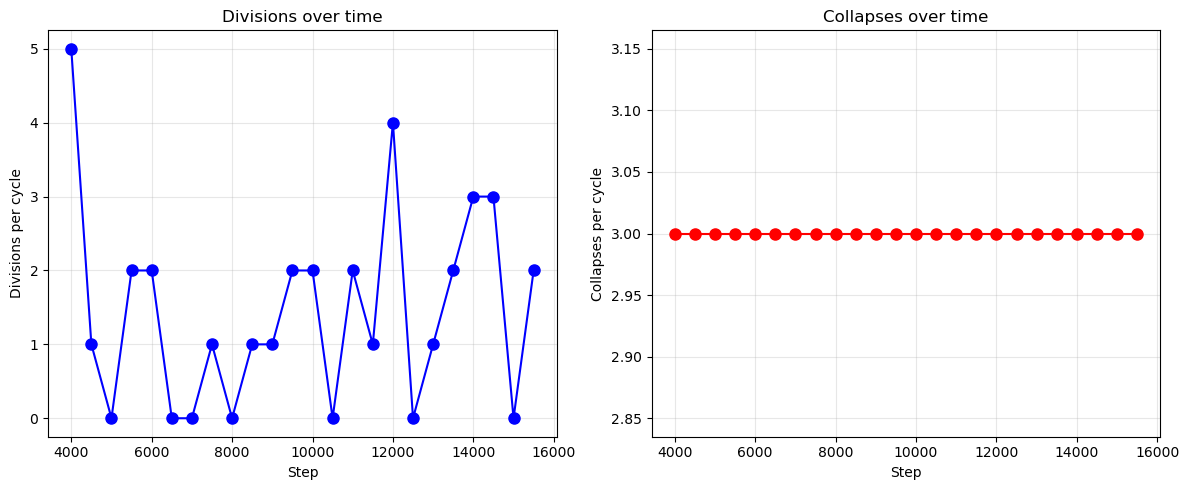

  ✓ Highlighted 2 new vertices in red
Visualization saved at step 15500
Final checkpoint saved to: ../../Figure_6_reviewed/with_apoptosis_0.0005/30_percent_line_tension_1.5_50_patches_seed_1_no_pressure_increase_3.5_div_sim_3/checkpoint_final.pkl


In [339]:
# ============================================================
# 2. CHECK COLUMNS EXIST (don't create them)
# ============================================================

v = cellmap.vert_df

# Verify columns exist
required_cols = ["new_vert_id", "parent_vert_id", "birth_step", "divided_step"]
for col in required_cols:
    if col not in v.columns:
        raise ValueError(f"Column '{col}' missing from vert_df — this should NOT happen!")

print("All tracking columns exist ✓")

# Get next available ID for new vertices
next_new_vert_id = int(v["new_vert_id"].max()) + 1
print(f"Next vertex ID: {next_new_vert_id}")

# Check current birth_step distribution
print(f"Vertices with birth_step == 0: {len(v[v['birth_step'] == 0])}")
print(f"Vertices with birth_step == 3500: {len(v[v['birth_step'] == 3500])}")

# ============================================================
# 3. SETUP PARAMETERS
# ============================================================

# Simulation parameters — continue from 3500
TOTAL_STEPS = 12000           # Total additional steps (3500 → 18500)
STEPS_PER_CYCLE = 500         # Save every 500 steps
RELAX_STEPS = 500             # Steps to relax after divisions

# Division parameters
EDGE_SUM_THRESHOLD = 3.5      # Changed back to original
DIVISION_DISTANCE = 0.01

# Collapse (apoptosis) parameters
COLLAPSE_FRACTION_PER_REMODEL = 0.0005  # 0.05% of inside edges per cycle
RELAX_AFTER_COLLAPSE = 10               # Relax steps after collapses

# Output directory
OUTPUT_DIR = "../../Figure_6_reviewed/with_apoptosis_0.0005/30_percent_line_tension_1.5_50_patches_seed_1_no_pressure_increase_3.5_div_sim_3"

# Starting step counter (continue from 3500)
STARTING_STEP = 3500

# ============================================================
# 4. DEFINE HELPER FUNCTIONS
# ============================================================

def relax(cellmap, nsteps: int):
    """Run mechanical relaxation without topological changes."""
    if nsteps <= 0:
        return cellmap
    energyContributions_model.compute_energy(cellmap)
    cellmap_out, _, _, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, int(nsteps)
    )
    return cellmap_out

def ensure_new_vert_ids(cellmap, next_id):
    """Assign unique IDs to any new vertices (from collapses etc)."""
    vdf = cellmap.vert_df
    if "new_vert_id" not in vdf.columns:
        vdf["new_vert_id"] = np.nan
    missing = vdf["new_vert_id"].isna()
    if missing.any():
        n = int(missing.sum())
        vdf.loc[missing, "new_vert_id"] = np.arange(next_id, next_id + n, dtype=int)
        next_id += n
    return next_id

def save_visualization_with_new_vertices(cellmap, geom, current_step, output_dir, divisions_count, collapses_count):
    """
    Create and save visualization with new vertices (birth_step == current_step) highlighted in red.
    """
    # Find vertices born at this step
    new_vert_ids = cellmap.vert_df[cellmap.vert_df["birth_step"] == current_step].index.tolist()
    
    fig, ax = plot_coloured_edges_with_new_vertices(
        cellmap,
        geom,
        new_vert_ids=new_vert_ids,
        col="line_tension",
        low_colour="mediumturquoise",
        high_colour="orange",
        threshold=155,
        width=3.0,
        show_axes=True,
        xlim=(-30, 70),
        ylim=(-30, 70),
        tick_spacing=10,
        new_vert_colour="red",
        new_vert_size=100,
        figsize=(10, 10),
        title=f"Step {current_step} | Div: {divisions_count} | Col: {collapses_count}",
        show_old_vertices=False,
    )
    
    plt.savefig(os.path.join(output_dir, f"progress_{current_step:06d}.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Visualization saved at step {current_step}")

# ============================================================
# 5. MAIN LOOP: EXPAND WITH DIVISIONS & COLLAPSES
# ============================================================

print(f"\n{'='*60}")
print(f"Continuing expansion from step {STARTING_STEP}")
print(f"Total additional steps: {TOTAL_STEPS} (to step {STARTING_STEP + TOTAL_STEPS})")
print(f"Saving every {STEPS_PER_CYCLE} steps")
print(f"{'='*60}\n")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Statistics
division_stats = []
collapse_stats = []

# Save initial state at step 3500
initial_step = STARTING_STEP
with open(os.path.join(OUTPUT_DIR, f"checkpoint_{initial_step:06d}.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Initial checkpoint saved at step {initial_step}")

# Save initial visualization using the new style
new_vert_ids_initial = cellmap.vert_df[cellmap.vert_df["birth_step"] == initial_step].index.tolist()
fig, ax = plot_coloured_edges_with_new_vertices(
    cellmap,
    geom,
    new_vert_ids=new_vert_ids_initial,
    col="line_tension",
    low_colour="mediumturquoise",
    high_colour="orange",
    threshold=155,
    width=3.0,
    show_axes=True,
    xlim=(-30, 70),
    ylim=(-30, 70),
    tick_spacing=10,
    new_vert_colour="red",
    new_vert_size=100,
    figsize=(10, 10),
    title=f"Step {initial_step} | Starting point for expansion",
    show_old_vertices=False,
)
plt.savefig(os.path.join(OUTPUT_DIR, f"progress_{initial_step:06d}.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Initial visualization saved at step {initial_step}")

#cellmap.face_df['prefered_area'] *= 1.2

# Main expansion loop
for cycle in range(1, int(TOTAL_STEPS / STEPS_PER_CYCLE) + 1):
    current_step = STARTING_STEP + cycle * STEPS_PER_CYCLE
    print(f"\n{'='*60}")
    print(f"Cycle {cycle}: Step {current_step}")
    print(f"{'='*60}")

    # --------------------------------------------------------
    # Step 1: Identify inside vertices
    # --------------------------------------------------------
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 2: COLLAPSES (apoptosis)
    # --------------------------------------------------------
    current_collapses = 0
    
    # Identify inside edges
    valid_inside_edges = [e for e in inside_edges if e in cellmap.edge_df.index]
    n_inside = len(valid_inside_edges)
    target_collapse = int(np.floor(COLLAPSE_FRACTION_PER_REMODEL * n_inside))
    target_collapse = max(0, min(target_collapse, n_inside))
    
    if target_collapse > 0:
        edges_to_collapse = np.random.choice(valid_inside_edges, size=target_collapse, replace=False)
        for edge in edges_to_collapse:
            try:
                cellmap = collapse_single_edge(
                    cellmap, geom, energyContributions_model, edge
                )
                current_collapses += 1
            except Exception as e:
                print(f"  Warning: collapse failed for edge {edge}: {e}")
    
    print(f"  Collapses: {current_collapses}/{target_collapse}")
    
    # Reset indices after collapses
    cellmap.reset_index()
    cellmap.reset_topo()
    next_new_vert_id = ensure_new_vert_ids(cellmap, next_new_vert_id)
    
    # Relax after collapses
    if RELAX_AFTER_COLLAPSE > 0:
        cellmap = relax(cellmap, RELAX_AFTER_COLLAPSE)
        cellmap.reset_index()
        cellmap.reset_topo()
    
    # Re-identify boundaries after collapses
    boundary_edges, boundary_faces, inside_edges, outside_edges, \
        inside_faces, inside_vertices, outside_vertices = \
        auxFunctions.identify_boundary_layers(cellmap, 1)

    # --------------------------------------------------------
    # Step 3: Perform divisions (using auxFunctionsExpansion.identify_vertices_to_divide)
    # --------------------------------------------------------
    vertices_to_divide = auxFunctionsExpansion.identify_vertices_to_divide(
        cellmap, inside_vertices, EDGE_SUM_THRESHOLD
    )
    
    print(f"  Found {len(vertices_to_divide)} vertices above threshold")

    current_divisions = 0

    if len(vertices_to_divide) > 0:
        divided_count = 0
        
        for v in vertices_to_divide:  # NO CAP — try ALL vertices
            try:
                cellmap, parent_vert, new_vert, new_edge, opp_edge = split_vertex(
                    cellmap, v, geom, energyContributions_model, DIVISION_DISTANCE, retry_attempts=3
                )
                
                if new_vert is not None:
                    # Record lineage with existing columns
                    parent_id = int(cellmap.vert_df.loc[parent_vert, "new_vert_id"])
                    cellmap.vert_df.loc[parent_vert, "divided_step"] = current_step
                    cellmap.vert_df.loc[new_vert, "new_vert_id"] = next_new_vert_id
                    cellmap.vert_df.loc[new_vert, "parent_vert_id"] = parent_id
                    cellmap.vert_df.loc[new_vert, "birth_step"] = current_step
                    next_new_vert_id += 1
                    divided_count += 1
                    
            except Exception as e:
                print(f"  Warning: division failed for vertex {v}: {e}")
        
        current_divisions = divided_count
        print(f"  Performed {current_divisions} divisions")

        cellmap.reset_index()
        cellmap.reset_topo()

    division_stats.append(current_divisions)
    collapse_stats.append(current_collapses)

    # --------------------------------------------------------
    # Step 4: Save post-division checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}_postdiv.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Post-division checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 5: Energy minimization / relaxation
    # --------------------------------------------------------
    print(f"  Relaxing for {RELAX_STEPS} steps...")
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, RELAX_STEPS
    )
    print(f"  Relaxation complete.")

    # --------------------------------------------------------
    # Step 6: Save checkpoint
    # --------------------------------------------------------
    with open(os.path.join(OUTPUT_DIR, f"checkpoint_{current_step:06d}.pkl"), "wb") as f:
        pickle.dump(cellmap, f)
    print(f"  Checkpoint saved at step {current_step}")

    # --------------------------------------------------------
    # Step 7: Save visualization
    # --------------------------------------------------------
    save_visualization_with_new_vertices(
        cellmap, 
        geom, 
        current_step, 
        OUTPUT_DIR, 
        current_divisions,
        current_collapses
    )

    # --------------------------------------------------------
    # Step 8: Update division stats
    # --------------------------------------------------------
    np.savetxt(os.path.join(OUTPUT_DIR, "division_stats.txt"), division_stats)
    np.savetxt(os.path.join(OUTPUT_DIR, "collapse_stats.txt"), collapse_stats)

# ============================================================
# 6. FINAL SUMMARY
# ============================================================

print(f"\n{'='*60}")
print("EXPANSION COMPLETE!")
print(f"Total divisions: {sum(division_stats)}")
print(f"Total collapses: {sum(collapse_stats)}")
print(f"Final vertex count: {len(cellmap.vert_df)}")
print(f"Final edge count: {len(cellmap.edge_df)}")
print(f"Output saved to: {OUTPUT_DIR}")
print(f"{'='*60}")
#
# Plot division and collapse statistics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

steps = [STARTING_STEP + i * STEPS_PER_CYCLE for i in range(1, len(division_stats) + 1)]

ax1.plot(steps, division_stats, 'bo-', markersize=8)
ax1.set_xlabel('Step')
ax1.set_ylabel('Divisions per cycle')
ax1.set_title('Divisions over time')
ax1.grid(True, alpha=0.3)

ax2.plot(steps, collapse_stats, 'ro-', markersize=8)
ax2.set_xlabel('Step')
ax2.set_ylabel('Collapses per cycle')
ax2.set_title('Collapses over time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "division_collapse_stats.png"), dpi=150)
plt.show()

# Save final visualization
save_visualization_with_new_vertices(
    cellmap, 
    geom, 
    STARTING_STEP + TOTAL_STEPS, 
    OUTPUT_DIR, 
    division_stats[-1] if division_stats else 0,
    collapse_stats[-1] if collapse_stats else 0
)

# Save final cellmap
with open(os.path.join(OUTPUT_DIR, "checkpoint_final.pkl"), "wb") as f:
    pickle.dump(cellmap, f)
print(f"Final checkpoint saved to: {OUTPUT_DIR}/checkpoint_final.pkl")

In [1]:
pwd

'/home/veronika/Documents/2D-lymph-node-vertex-model/notebooks/TDLNs'